# $$ \textbf{Sinais e Sistemas Dinâmicos}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Análise Linear de Sistemas Dinâmicos, José C. Geromel, Alvaro G. B. Palhares. ed. Blucher, 2019.]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## 1. Apresentação do Curso

**Sinais e Sistemas Dinâmicos**

60 horas – 04 Créditos

**Pré-requisitos:** Séries e Equações Diferenciais Ordinárias

**Ementa:** Sinais em tempo contínuo e em tempo discreto; energia e potência de sinais; classificações e propriedades de sinais; transformações da variável independente; classificação e propriedades de sistemas: memória, invertibilidade, causalidade, estabilidade, invariância temporal, linearidade; sistemas lineares e invariantes no tempo (LIT) e suas propriedades; convolução e resposta a impulso unitário; equações diferenciais e de diferença finita; associação de sistemas e representação em diagrama de blocos; representação de sinais periódicos em série de Fourier (tempo contínuo e discreto); propriedades da série de Fourier; filtragem: filtros seletivos de frequência, passa alta, passa baixa, passa faixa; filtro sem tempo discreto: recursivo, não recursivo; transformada de Fourier e suas propriedades; caracterização de sinais no domínio de frequências; gráficos de Bode; discretização por amostragem; sistemas de comunicação (AM e FM); transformada de Laplace; caracterização de sistemas usando a transformada de Laplace; filtros de Butterworth; transformada z e suas aplicações; função de transferência de tempo discreto.

**Referências:**

- Sinais e Sistemas. A. V. Oppenheim, A. S. Willsky, 2a ed. Prentice Hall, Pearson Education BR, 1997

- Signals and Systems. S. Haykin and B. V. Veen, Wiley, 2005.

- Sinais e Sistemas Lineates, B. P. Lathi; 2. ed. Porto Alegre: Bookman, 2008.

- **Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019.**

- **Análise Linear de Sistemas Dinâmicos, José C. Geromel, Alvaro G. B. Palhares. ed. Blucher, 2019.**

**Avaliações:  AVi - avaliações, Li - $\sum$ (listas) da unidade i**

- AV1 (7,0) e L1 (3,0): 21 de agosto

- AV2 (7,0) e L2 (3,0): 25 de setembo

- AV3 (7,0) e L3 (3,0): 06 de novembro

- Reposição  (10,0): 08 de novembro

- Final  (10,0): 13 de novembro

### 1.1 Apresentação Pessoal

- e-mail: jairo@ci.ufpb.br - Sala 207

- horário de atendimento: 24T26 e 3M26 (presencial/virtual)

- [Currículo Lattes](http://lattes.cnpq.br/0796077542730627)

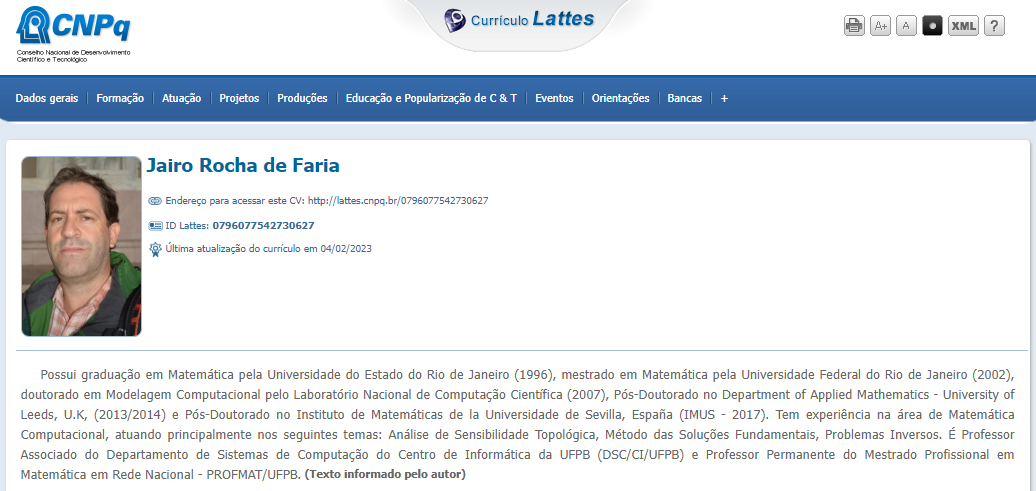


### 1.2 Metodologia

Neste curso incentivamos a sala de aula invertida (*flipped classroom*), onde o conteúdo é estudado individualmente e as atividades (exemplos, exercícios) são realizados em sala de aula - permitindo que o(a) estudante assuma o protagonismo de seu aprendizado além de outras vantagens como: maior participação da turma, ensino personalizado e otimização do tempo. 

Para tanto, as lições da semana são disponibilizadas com antecedência na plataforma SIGAA.


## 2. Sinais



### 2.1 Introdução


 A todo instante estamos imersos em um ambiente que está pleno de sinais:
 
 - as ondas de rádio e de televisão; 
 - as ondas que chegam no nosso telefone fixo (através do fio) e no celular (através do ar) sabemos classificar, corretamente, como sinais; 
 - mais ainda, o número de ovos colhidos cada dia em um aviário também é um sinal. 
 
 De forma bastante genérica, **todo conjunto de dados organizados segundo uma ordem preestabelecida é um sinal.**
 
 A ordenação mencionada é realizada com o uso de uma variável independente, em geral, **o tempo $t \in \mathbb{R}$, que é número real em tempo contínuo**, ou **$k \in \mathbb{Z}$, um número inteiro em tempo discreto**.

Para tornar mais claro este conceito vamos imaginar que um hospital tenha armazenado na posiçāo $(i, j)$ de uma matriz $A$ o número de batimentos cardíacos de cada um dos seus pacientes $i \in[1,100]$ durante cada hora $j \in[1,168]$ de uma semana. Esta matriz, com elementos $a_{i j}$, contém 16.800 números, dispostos em 100 linhas e 168 colunas, que podem ser facilmente acessados. 

Por exemplo, para saber como se comportou o coração do paciente número $i=57$, basta verificar o sinal $a_{i j}$ para $i=57$ e todo $j \in[1,168]$. Da mesma forma, se desejarmos saber como estavam os pacientes em uma determinada hora $j=127$, basta analisar o sinal $a_{i j}$ para $j=127$ e todo $i \in[1,100]$. No primeiro caso a variável independente é o tempo, mas no segundo é o número atribuído a cada paciente. 

Como veremos mais adiante, **os sinais são representados matematicamente por funções que levam elementos de $\mathbb{R}$ ou $\mathbb{Z}$ para $\mathbb{R}$ ou $\mathbb{C}$.**

Neste sentido, podemos manipular, transformar e representar sinais através da aplicação de qualquer operação matemática válida, com o objetivo de armazená-lo ou dele extrair informações da maneira mais simples e eficiente possível.

**Exemplo 2.1** (Série histórica de vazões) A operação eficiente das várias usinas hidrelétricas que temos no nosso país requer o conhecimento antecipado das vazōes de água nos diversos rios que alimentam cada bacia hidrográfica. 


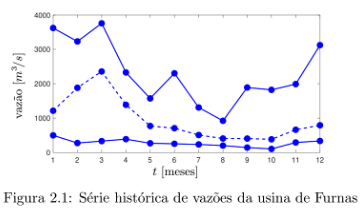

A Figura 2.1 mostra as vazões mínima e máxima mensais expressas em $\left[\mathrm{m}^3 / \mathrm{s}\right]$ calculadas a partir de medições realizadas mensalmente entre os anos de 1931 e 2014 no reservatório da usina de Furnas. Entre as vazões mínima e máxima desenhadas em linhas contínuas, colocamos em linha tracejada a vazão média mensal do ano 1952. Podemos entender esta figura como a representação gráfica de um sinal que tem como variável independente o tempo.

O exemplo que acabamos de apresentar serve para colocar em evidência algumas características importantes dos sinais. Elas permitem dividi-los em classes que são tratadas através de ferramentas matemáticas específicas. Para bem evidenciar as diferenças mais marcantes entre os diversos sinais, vamos denotar um sinal genérico na forma de uma função
$$
s: \mathfrak{D} \rightarrow \mathfrak{J} \subset \mathfrak{C}
$$
com domínio $\mathfrak{D}$ e imagem $\mathfrak{J}$ contida no contradomínio $\mathfrak{C}$. 



Podemos descrever as seguintes classes:

- **Sinais a tempo contínuo ou sinais a tempo discreto**: os sinais a tempo contínuo são aqueles em que para todos $t_i, t_j \in \mathfrak{D}$, com $t_i < t_j$, existe $t_k \in \mathfrak{D}$ tal que $t_i < t_k < t_j$. Isto é, $t$ é uma variável contínua. Em contraposição, quando $k$ é uma variável discreta (isto é, existem $k_i < k_j$, tais que $(k_i,k_j) \cap \mathfrak{D} = \varnothing$). Assim, os sinais a tempo contínuo são expressos por funções do tipo $s(t)$, definidas para todo $t \in \mathfrak{D}$, enquanto os sinais a tempo discreto são modelados por sequências numéricas do tipo $s(k)$, definidas para todo $k \in \mathfrak{D}$. <!---Os sinais a tempo contínuo são aqueles em que o domínio *é um subconjunto denso* dos números reais, isto é, $\mathfrak{D} \subset \mathbb{R}$. São, portanto, expressos por funções do tipo $s(t)$, definidas para todo $t \in \mathfrak{D}$. Os sinais a tempo discreto são aqueles em que o domínio é *um subconjunto dos números inteiros*, isto é, $\mathfrak{D} \subset \mathbb{Z}$. São modelados por sequências numéricas do tipo $s(k)$, definidas para todo $k \in \mathfrak{D}$.---> Pode-se obter um sinal a tempo discreto a partir de um sinal a tempo contínuo através de uma operação denominada **amostragem**, que é caracterizada por um determinado período $T>0$, ou seja, $s(k)=h(k T)$ é o valor do sinal a tempo contínuo $h(t)$ avaliado, periodicamente, nos instantes de amostragem $t=k T$ para todo $k \in \mathbb{Z}$.



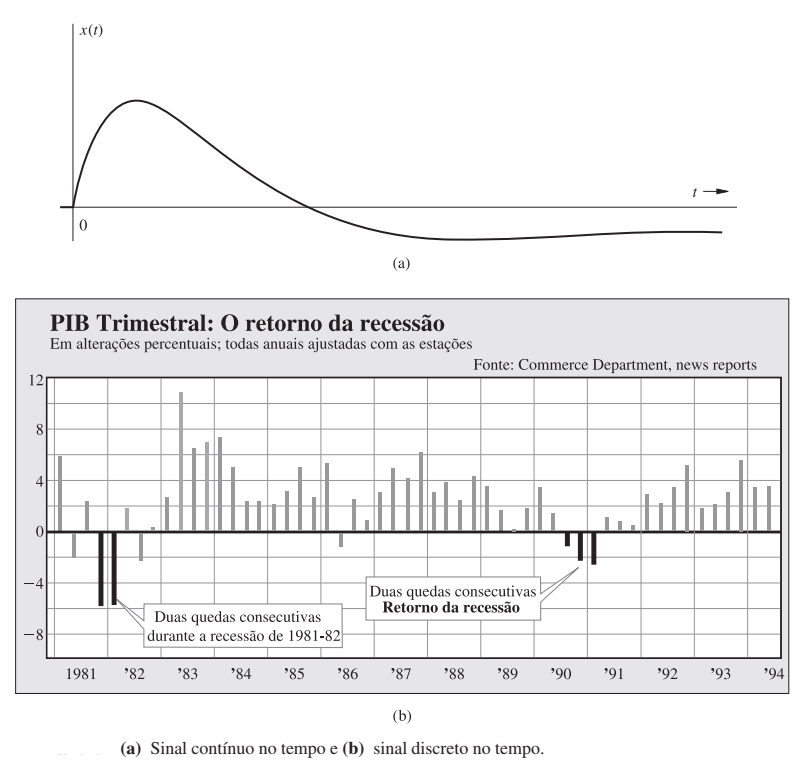

- **Sinais analógicos ou sinais digitais**: Um sinal é dito analógico se a sua amplitude pode assumir qualquer valor em uma faixa contínua, o que significa que a amplitude de um sinal analógico pode assumir infinitos valores. Se, no entanto, a sua imagem for um conjunto com um número finito de elementos, ele será um sinal digital. Um dos mais conhecidos é o **sinal binário** para o qual a sua imagem $\mathfrak{J}=\{0,1\}$ tem apenas dois elementos. Pode-se também obter um sinal digital a partir de um sinal analógico através de um processo chamado **codificação**. Neste processo, o sinal analógico é amostrado e, em seguida, é representado por um número binário que pode assumir apenas um número finito de valores que depende do número de bits disponível. Quanto maior o número de bits, mais próximo o sinal digital se torna do sinal analógico original.

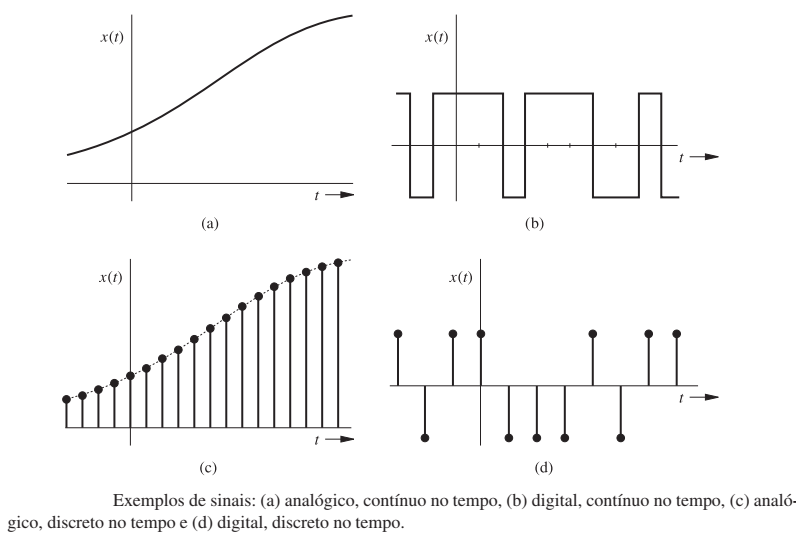

- **Sinais periódicos ou sinais aperiódicos**: Um sinal $s(t)$ é periódico se existir $T_0>0$ tal que $s(t)=s\left(t+T_0\right)$, em que $t+T_0 \in \mathfrak{D}$ para todo $t \in \mathfrak{D}$ e aperiódico caso contrário. O menor valor de $T_0>0$ é denominado **período fundamental**. É claro que a restriçāo $t+T_0 \in \mathfrak{D}$ delimita os possíveis valores para $T_0$. De fato, para sinais a tempo contínuo $T_0 \in \mathbb{R}_{+}$e para sinais a tempo discreto $T_0 \in \mathbb{N}$. Nota-se imediatamente que para ser periódico é necessário que o sinal seja definido em todo o intervalo de tempo correspondente ao seu domínio, isto é, $t \in \mathbb{R}$ ou $k \in \mathbb{Z}$.

- **Sinais determinísticos ou sinais estocásticos**: Sinais perfeitamente conhecidos, como por exemplo a tensão em um capacitor de um circuito RC alimentado por uma fonte de tensão conhecida, são denominados sinais determinísticos. Os sinais que só podem ser conhecidos em termos probabilísticos, tais como sua média e seu desvio padrão em cada instante de tempo, são denominados sinais estocásticos. Por exemplo, a vazão em uma usina pode ser modelada como um sinal estocástico. Este tipo de modelagem permite fazer estimações sobre comportamentos futuros que são bastante úteis.

Essas classes são as mais importantes para os nossos propósitos. De fato, elas são suficientemente delimitadas, mas ao mesmo tempo bastante abrangentes, o que torna conveniente estabelecer estudos específicos para cada uma delas. Por exemplo, sinais periódicos são mais simples de ser analisados pois são completamente conhecidos desde que se conheça o seu comportamento em um intervalo de tempo correspondente a apenas um único período.

**Exemplo 2.2** 

- O sinal $s(t)=\operatorname{sen}(t)$ tem domínio $\mathbb{R}$ e imagem $[-1,1] \subset \mathbb{R}$. É um sinal a tempo contínuo, analógico e periódico, com período $T_0=2 \pi$. 

- O sinal $s(k)=\operatorname{sen}(k)$ tem domínio $\mathbb{Z}$ e contradomínio $[-1,1]$. Portanto, trata-se de um sinal a tempo discreto, analógico e aperiódico. É aperiódico pois a igualdade $\operatorname{sen}\left(k+N_0\right)=\operatorname{sen}(k)$ não tem como ser satisfeita para todo $k \in \mathbb{Z}$ e algum $N_0 \in \mathbb{N}$. 

- O sinal $s(k)=\operatorname{sen}((\pi / 2) k)$ tem domínio $\mathrm{Z}$ e imagem $\{-1,0,1\}$. Verificamos imediatamente que se trata de um sinal a tempo discreto, digital e periódico, com periodo $N_0=4$.

**Exemplo 2.3** O sinal $s(t)=s_1(t)+s_2(t)$ é a soma de dois sinais periódicos $s_1(t)=$ $\operatorname{sen}(\pi t)$ com período $T_{01}=2[\mathrm{~s}]$ e $s_2(t)=\operatorname{sen}(4 t)$ com período $T_{02}=\pi / 2[\mathrm{~s}]$, mas não é periódico. Note que, se assim fosse, $s(t)=s\left(t+T_0\right)=s_1\left(t+T_0\right)+s_2\left(t+T_0\right)$. Como $s_1(t)=s_1\left(t+n T_{01}\right)$ e $s_2(t)=s_2\left(t+m T_{02}\right) \operatorname{com} m, n \in \mathbb{N}$, então, $n T_{01}=m T_{02}=T_0$ e, portanto, $T_{01} / T_{02}=m / n$ deve ser um número racional. No caso em questão, $T_{01} / T_{02}=$ $4 / \pi$, o que indica que o sinal $s(t)$ é aperiódico. 

Se o segundo sinal for $s_2(t)=\cos (8 \pi t / 3)$ com período $T_{02}=3 / 4[\mathrm{~s}]$, então $T_{01} / T_{02}=8 / 3$, o que indica que o sinal $s(t)$ torna-se periódico. O seu periodo é obtido determinando-se o mínimo múltiplo comum de ambos os períodos $\{2,3 / 4\}$, o que fornece $T_0=6[\mathrm{~s}]$. 

In [2]:
'''lcm (* least common multiple*) =  mmc (mínimo múltiplo comum)
adapação para números racionais '''
def lcm_float(a, b, precision):
    a = round(a, precision)
    b = round(b, precision)
    return math.lcm(int(a*10**precision), int(b*10**precision))/10**precision

In [3]:
lcm_float(2, 3/4, 2)

6.0

Como pode ser observado na **Figura 2.2**, esta operação identifica o menor intervalo de tempo $t \in\left[0, T_0\right]$, com $T_0>0$, em que os ciclos periódicos de ambos os sinais coincidem.

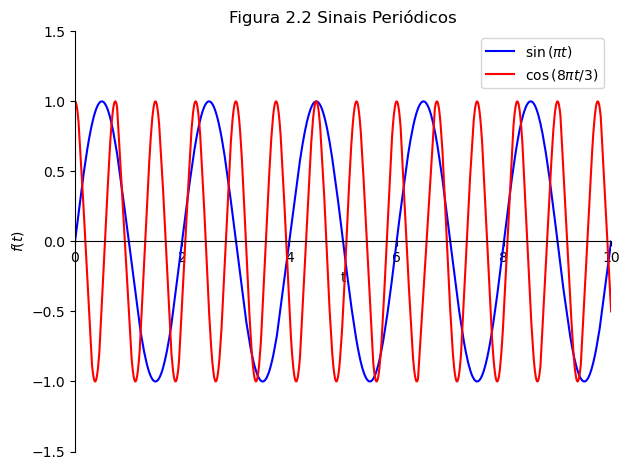

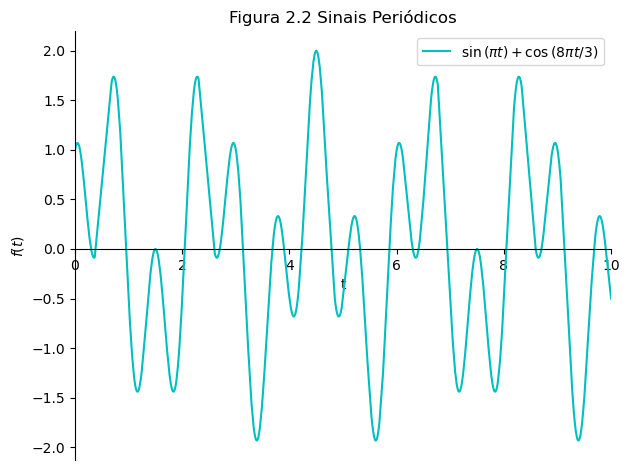

(None, None)

In [4]:
t = sym.Symbol('t')

s1 = sin(pi*t)
s2 = cos(8*pi*t/3)

p1 = sym.plot(s1, s2, xlim=[0.0, 10.0], ylim=[-1.5, 1.5], \
              title='Figura 2.2 Sinais Periódicos', xlabel='t', legend=True, show=False)
p2 = sym.plot(s1 + s2, xlim=[0.0, 10.0], \
              title='Figura 2.2 Sinais Periódicos', xlabel='t', legend=True, show=False)
p1[0].line_color = 'b'
p1[1].line_color = 'r'
p2[0].line_color = 'c'
p1.show(), p2.show()

A seguir, passamos a estudar algumas propriedades básicas dos sinais a tempo contínuo e a tempo discreto. Nosso objetivo é introduzir manipulações e colocar em evidência várias propriedades algébricas que permitam tornar operacional o cálculo envolvendo esta entidade matemática.

### 2.2 Propriedades Básicas
É importante sabermos como operar com sinais de uma mesma classe. Daquelas descritas anteriormente, as duas mais abrangentes são as que caracterizam os sinais a tempo contínuo e a tempo discreto. As ferramentas matemáticas que devemos empregar para o estudo de cada uma delas, embora tenham como base os mesmos conceitos e princípios, exigem tratamentos diferenciados e específicos. Por este motivo, vamos estudá-las separadamente para podermos colocar em evidência as suas semelhanças e eventuais diferenças.

#### 2.2.1 Sinais a Tempo Contínuo
Inicialmente, consideramos os sinais com domínio $\mathbb{R}$ e imagem $\mathbb{C}$ para, em seguida, fazermos as simplificações necessárias para tratarmos sinais reais, que são aqueles com imagem no conjunto dos números reais $\mathbb{R}$. 

O conceito básico, do qual todos os demais derivam, é o de produto escalar de dois sinais, que é introduzido através da seguinte definição.

**Definição 2.1 (Produto escalar)** O **produto escalar** de dois sinais $f(t)$ e $g(t)$ com o mesmo domínio $\mathbb{R}$ e imagem $\mathbb{C}$ é um número complexo dado por
$$
\langle f, g\rangle=\int_{-\infty}^{\infty} f(t) g(t)^* d t
$$


Pode-se provar que os axiomas da 

- simetria conjugada $\left(\langle f, g\rangle=\langle g, f\rangle^*\right)$, 

- da distributividade $(\langle f+h, g\rangle=\langle f, g\rangle+\langle h, g\rangle)$, 

- da homogeneidade $(\langle\lambda f, g\rangle=\lambda\langle f, g\rangle$ para $\lambda \in \mathbb{C})$, e 

- da positividade $(\langle f, f\rangle \geq 0$ e é igual a zero se e apenas se $f(t)=0$ para todo $t \in \mathbb{R}$ ) 

são válidos para a definição acima (sendo a positividade, a menos de um conjunto de medida nula, restrita ao conjunto dos sinais contínuos por partes). 

Em particular, o axioma da positividade permite calcular a **norma induzida** de um sinal, que é um número real não negativo dado por
$$
\|f\|=\sqrt{\langle f, f\rangle}=\sqrt{\int_{-\infty}^{\infty}|f(t)|^2 d t}
$$
em que é importante observar a possibilidade de a integral divergir. Este é o caso de sinais limitados inferiormente no tempo por uma constante. A norma de um sinal constante no tempo é $+\infty$. Para que a sua norma seja finita é necessário (mas não suficiente) que $|f(t)| \rightarrow 0$ quando $|t| \rightarrow \infty$. Podemos então concluir que todo sinal periódico tem norma infinita. Uma outra medida do tamanho de um sinal é dada em seguida.



In [5]:
t = sym.Symbol('t')
f = 1/t**2

Norma = sqrt(integrate(f*f,(t,-oo,+oo)))
Norma

oo

**Definição 2.2 (Valor eficaz)** O **valor eficaz** de um sinal $f(t)$ com domínio $\mathbb{R}$ e imagem $\mathbb{C}$ é um número real não negativo dado por
$$
\|f\|_{e f}=\sqrt{\lim _{\tau \rightarrow \infty} \frac{1}{2 \tau} \int_{-\tau}^\tau|f(t)|^2 d t}
$$
Esta definição indica que o valor eficaz de um sinal tem a simples interpretação de valor médio do seu módulo. Desta forma, sob as mesmas condições anteriores, para um sinal limitado no tempo por uma constante $\alpha$, obtém-se $\|f\|_{e f} \leq |\alpha|$. 

O valor eficaz de um sinal constante no tempo é igual ao módulo desta constante. 

De maneira similar, o valor eficaz de um sinal periódico é igual ao valor eficaz calculado em apenas um período. 

De fato, particionando $[-\tau, \tau]$ em segmentos de tamanho $T_0>0$, o período do sinal, podemos calcular
$$
\begin{aligned}
\|f\|_{e f}^2 & =\lim _{m \rightarrow \infty} \frac{1}{2 m} \sum_{n=-m}^{m - 1} \frac{1}{T_0} \int_{n T_0}^{(n+1) T_0}|f(t)|^2 d t \\
& =\frac{1}{T_0} \int_0^{T_0}|f(t)|^2 d t
\end{aligned}
$$

Os exemplos resolvidos em seguida permitem ilustrar os diversos aspectos dessas duas definiçōes no contexto de sinais a tempo contínuo, periódicos ou aperiódicos. O objetivo é deixar claro como essas grandezas são calculadas e quais são as interpretaçōes possíveis que resultam dos cálculos realizados.


**Exemplo 2.4** Considere o sinal $f(t)=e^{\alpha t}$ com domínio $\mathbb{R}$ e imagem $\mathbb{R}_{+}$. Sua norma sempre é $+\infty$ para qualquer valor $\alpha \in \mathbb{R}$. 

Seu valor eficaz é $+\infty$ para todo $\alpha \neq 0$ e é igual a $\|f\|_{e f}=1$ para $\alpha=0$. 

Note que o sinal $g(t)=e^{(\alpha+j \beta) t}$ com domínio $\mathbb{R}$ e imagem $\mathbb{C}$ é tal que $|g(t)|=f(t)=|f(t)|$ para todo $t \in \mathbb{R}$. Assim sendo, a norma e o valor eficaz de $g$ e de $f$ coincidem. A norma e o valor eficaz de $g(t)$ não dependem de $\beta \in \mathbb{R}$.

In [6]:
a = sym.Symbol('a', real = True, negative = True)
t = sym.Symbol('t')
T = sym.Symbol('T')
f = exp(a*t)

Norma = sqrt(integrate(f*f,(t,-oo,+oo)))#, conds = 'none'
Norma

oo

In [7]:
EF = sqrt(limit(integrate(f*f,(t,-T,+T))/(2*T),T,oo ))
EF

oo

**Exemplo 2.5** Considere o sinal $f(t)=a \operatorname{sen}(\omega t)$ com domínio $\mathbb{R}$ e imagem $[-a, a] \subset \mathbb{R}$, em que $a$ e $\omega$ são números reais positivos. Trata-se de um sinal periódico com período $T_0=2 \pi / \omega$ e, portanto, a sua norma é $+\infty$. Seu valor eficaz é determinado por,
$$
\begin{aligned}
\|f\|_{e f}^2 & =\frac{a^2 \omega}{2 \pi} \int_0^{2 \pi / \omega} \operatorname{sen}^2(\omega t) d t \\
& =\frac{a^2}{2 \pi} \int_0^{2 \pi} \operatorname{sen}^2(\xi) d \xi \\
& =\frac{a^2}{2 \pi} \int_0^{2 \pi} \frac{1-\cos (2 \xi)}{2} d \xi=\frac{a^2}{2}
\end{aligned}
$$

e, assim, $\|f\|_{e f}=a \sqrt{2}/ 2 $. Neste caso, nota-se que o valor eficaz do sinal não depende do seu período.

In [8]:
a = sym.Symbol('a', real = True, positive = True)
w = sym.Symbol('w', real = True, positive = True)
t = sym.Symbol('t')

f = a*sin(w*t)

EF = sqrt(limit(integrate(f*f,(t,-T,+T))/(2*T),T,oo ))
EF

sqrt(2)*a/2

**Exemplo 2.6** Considere o sinal periódico, com período $T_0$, definido para todo $t \in \mathbb{R}$, denominado dente de serra. O seu valor no intervalo de tempo correspondente ao primeiro período $ -T_0/2 < t \leq T_0 / 2$ é dado por $f(t)=a t, $ com $a>0$. A sua norma é $+\infty$. 

Utilizando novamente a definição, o seu valor eficaz é determinado, ou seja,
$$
\begin{aligned}
\|f\|_{c f}^2 & =\frac{a^2}{T_0} \int_{-T_0 / 2}^{T_0 / 2} t^2 d t \\
& =\frac{a^2 T_0^2}{12}
\end{aligned}
$$
e, assim, $\|f\|_{e f}=\frac{a T_0 \sqrt{3}}{6}$. Portanto, neste caso, o valor eficaz do sinal depende do seu período.

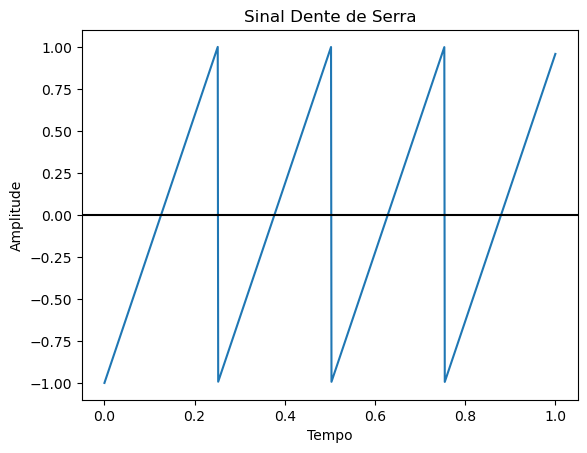

In [9]:
t = np.linspace(0, 1, 1000, endpoint=True) 
plt.plot(t, signal.sawtooth(25 * t)) # a = 25
plt.xlabel('Tempo') 
plt.ylabel('Amplitude') 
plt.title('Sinal Dente de Serra') 
  
plt.axhline(y=0, color='k') 
plt.show() 

In [10]:
a = sym.symbols('a', real = True, positive = True)
t = sym.symbols('t', real = True, positive = True)
T0 = sym.symbols('T0', real = True, positive = True)
f = a*t

EF = sqrt((integrate(f*f,(t,-T0/2,+T0/2))/T0))
EF

sqrt(3)*T0*a/6

Um aspecto interessante do cálculo de norma ocorre quando um sinal é obtido como resultado da combinaçāo linear de $m$ sinais elementares $f_1(t), \cdots, f_m(t)$, ou seja,
$$
g(t)=\sum_{i=1}^m c_i f_i(t)
$$
em que $c_i \in \mathbb{C}$ para todo $i=1, \cdots, m$ são escalares conhecidos. 

Os sinais elementares funcionam como se constituíssem uma base no espaço dos sinais, a partir da qual outros sinais mais complexos são construídos através de combinaçōes lineares adequadas. Aplicando a definiçāo de norma e fazendo uso da sua distributividade, obtemos
$$
\|g\|^2=\sum_{i=1}^m \sum_{n=1}^m c_i c_j^*\left\langle f_i, f_n\right\rangle
$$
o que coloca em evidência que a igualdade
$$
\|g\|^2=\sum_{i=1}^m\left|c_i\right|^2\left\|f_i\right\|^2
$$
se verifica para sinais elementares que satisfaçam as relações
$$
\left\langle f_i, f_n\right\rangle=\int_{-\infty}^{\infty} f_i(t) f_n(t)^* d t=0
$$
para todo $i \neq n=1, \cdots, m$. Estes sinais são ditos **ortogonais** e se, além disso, forem normalizados $\left\|f_i\right\|=1$ para todo $i=1, \cdots, m$ então tornam-se **ortonormais**. Neste caso, a igualdade $\|g\|^2=\sum_{i=1}^m\left|c_i\right|^2\left\|f_i\right\|^2$ se reduz a $\|g\|^2=\left|c_1\right|^2+\cdots+\left|c_m\right|^2$. 

É claro que o ponto central deste desenvolvimento situa-se no conhecimento ou na determinação de um conjunto de sinais ortonormais, sobretudo quando o número de sinais elementares for arbitrariamente grande. Este aspecto, por sua importancia específica, será objeto de análise detalhada a ser feita mais adiante.

**Definição 2.3 (Sinal par e sinal ímpar)** Um sinal $f(t)$ com domínio $\mathbb{R}$ é denominado **par** se $f(t)=f(-t)$ para todo $t \in \mathbb{R}$ E é denominado **ímpar** se $f(t)=-f(-t)$ para todo $t \in \mathbb{R}$.

Nota-se que, em ambos os casos, os valores de $f(t)$ em cada ponto simétrico do seu domínio $t>0$ e $t<0$ guardam alguma simetria entre si. É claro que um sinal qualquer pode não ser par nem ímpar, mas qualquer sinal pode ser decomposto na forma $f(t)=f_p(t)+f_i(t)$, em que $f_p(t)$ é a sua componente par e $f_i(t)$ é a sua componente ímpar. 

De fato, as componentes par e ímpar de um sinal qualquer $f(t)$ são dadas por
$$
\begin{aligned}
f_p(t) & =\frac{1}{2}(f(t)+f(-t)) \\
f_i(t) & =\frac{1}{2}(f(t)-f(-t))
\end{aligned}
$$

pois, a partir da simples aplicação da definição acima, conclui-se que o sinal $f_p(t)$ é par e que o sinal $f_i(t)$ é impar. 

É também possível verificar que, para qualquer sinal, as suas componentes par e ímpar são ortogonais. Esta importante propriedade decorre do cálculo do produto escalar
$$
\begin{aligned}
\left\langle f_p, f_i\right\rangle= & \int_{-\infty}^{\infty} f_p(t) f_i(t)^* d t \\
= & \frac{1}{4} \int_{-\infty}^{\infty}\left(|f(t)|^2+f(-t) f(t)^*\right) d t- \\
& -\frac{1}{4} \int_{-\infty}^{\infty}\left(|f(-t)|^2+f(t) f(-t)^*\right) d t \\
= & \frac{1}{4} \int_{-\infty}^{\infty} h(t) d t-\frac{1}{4} \int_{-\infty}^{\infty} h(-t) d t
\end{aligned}
$$
em que $h(t)=|f(t)|^2+f(-t) f(t)^*$. Como pode ser verificado pela simples mudança de variável $\tau=-t$, as duas integrais são iguais e assim temos $\left\langle f_p, f_i\right\rangle=0$. 

Em muitas situações é útil lembrar que, para qualquer sinal $f(t)$, o sinal produto a ele associado $s(t)=f(t) f(-t)$ é sempre um sinal par. Observe que o mesmo não ocorre com o sinal resultante da divisão $s(t)=f(t) / f(-t)$, ainda que esta operação possa ser realizada para todo $t \in \mathbb{R}$.

**Exemplo 2.7** Considere o sinal $f(t)=e^{\alpha t}$ com domínio $\mathbb{R}$ e imagem $\mathbb{R}_{+}$. Este sinal real não é par e também não é ímpar, mas as suas componentes são imediatamente calculadas como sendo $f_p(t)=\cosh (\alpha t)$ e $f_i(t)=\operatorname{senh}(\alpha t)$. 

O sinal $g(t)=e^{(\alpha+j \beta) t}$ com  domínio $\mathbb{R}$ e imagem $\mathbb{C}$ tem a componente par $g_p(t)=\cosh (\alpha t) \cos (\beta t)+j \operatorname{senh}(\alpha t) \operatorname{sen}(\beta t)$ e ímpar $g_i(t)=\operatorname{senh}(\alpha t) \cos (\beta t)+j \cosh (\alpha t) \operatorname{sen}(\beta t)$. 

É interessante notar que para $\alpha=$ 0 obtém-se $g_p(t)=\cos (\beta t)$ e $g_i(t)=j \operatorname{sen}(\beta t)$, de tal forma que a soma destas duas componentes reproduz o sinal original, como era de se esperar.

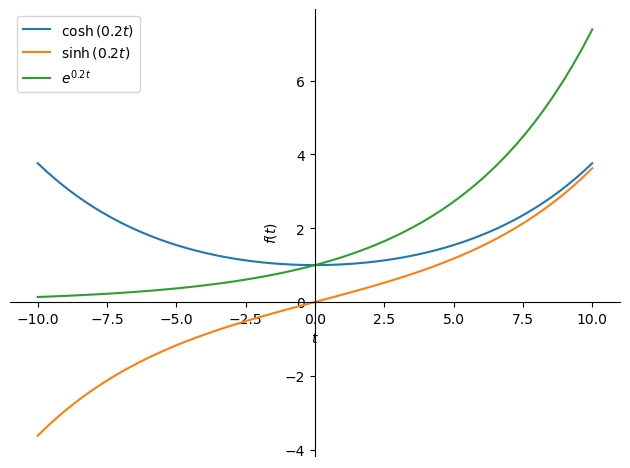

In [11]:
t = sym.Symbol('t')
sym.plot(cosh(.2*t),sinh(.2*t),exp(.2*t), legend = 'True')

**Exemplo 2.8 (Energia e Potência)** Um resistor com resistência unitária de $R=$ $1[\Omega]$, ao ser submetido a uma tensão $f(t)[\mathrm{V}]$, dissipa a potência instantânea $P(t)=$ $f(t)^2[\mathrm{~W}]$ e a energia
$$
E=\int_{-\infty}^{\infty} P(t) d t[\text { Joules }]
$$
Neste caso, sendo $f(t)$ um sinal com imagem em $\mathbb{R}$, verifica-se que $E=\|f\|^2$, ou seja, a norma ao quadrado do sinal de tensāo é igual ao valor total da energia dissipada no resistor. 

Por outro lado, se calcularmos a potência média dissipada em todo o intervalo de tempo $(-\infty, \infty)$ como sendo
$$
P_m =\lim _{\Delta t \rightarrow \infty} \frac{1}{2 \Delta t} \int_{-\Delta t}^{\Delta t} P(t) d t[\text { Watts] }
$$
então verifica-se imediatamente que $P_m =\|f\|_{e f}^2$. Ou seja, o valor eficaz ao quadrado do sinal de tensão é igual à potência média dissipada no resistor padrão. Estas duas interpretaçōes físicas ajudam a entender a natureza dos sinais segundo os valores (finitos ou não) da sua norma e do seu valor eficaz.

No estudo de sinais, existem algumas funçōes que são especiais e que, portanto, merecem ser apresentadas e estudadas de maneira mais detalhada. Todas elas sāo definidas no domínio real $\mathbb{R}$ e têm imagem neste mesmo conjunto.

- **Degrau unitário**: Trata-se de uma das funções mais importantes no estudo de sinais. Ela é definida por 
$$
v(t)= \begin{cases}1, & t \geq 0 \\ 0, & t<0\end{cases}
$$
observe que ela é descontínua em $t=0$, sendo que $v(0)=1$.
- **Retângulo unitário**: Trata-se de uma função usada para selecionar partes simétricas (em relação à origem) de sinais. Ela é definida na forma
$$
\vartheta(t)= \begin{cases}1, & -1 \leq t <1 \\ 0, & t < -1 \text{ ou } t \geq 1\end{cases}
$$
e tem dois pontos de descontinuidade que satisfazem $|t|=1$. Ao ser escrita como uma composição de dois degraus unitários deslocados, ou seja, $\vartheta(t)=$ $v(t+1)-v(t-1)$, os valores $\vartheta(-1)=1$ e $\vartheta(1)=0$ ficam determinados.

- **Seno normalizado**: $(\operatorname{sinc})$ Trata-se de uma função definida na forma
$$
\operatorname{sinc}(t)=\left\{\begin{array}{cc}
1, &  \quad t=0 \\
\operatorname{sen}(t) / t, &  \quad t \neq 0
\end{array}\right.
$$
Deve ser imediatamente notado que esta é uma função contínua em todos os pontos do seu domínio, em particular, em $t=0$. Ela se anula nos instantes $t_n=n \pi$ para todo $n \in \mathbb{Z}$



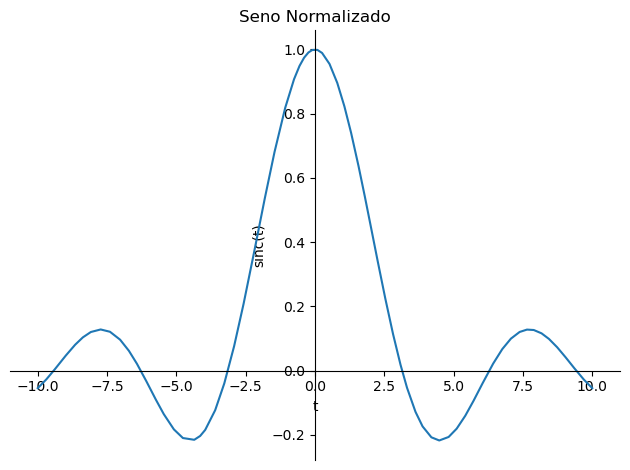

In [12]:
t = sym.Symbol('t')
s = sym.sinc(t)
p = sym.plot(s, title='Seno Normalizado', xlabel='t', ylabel='sinc(t)', legend=False, show=True)

Por fim, desejamos introduzir não uma função, mas um ente matemático que tem importância capital no estudo de sinais (e de sistemas). Trata-se do chamado 

- **impulso unitário**, que é denotado por $\delta(t)$ e é definido através das propriedades
$$
\delta(t)=0, \quad \forall t \neq 0; \quad \int_{-\infty}^{\infty} \delta(t) d t=1
$$
Como o impulso pode ser diferente de zero apenas em $t=0$, a integral acima exige que o valor do impulso em $t=0$ seja ilimitado. Várias são as possibilidades para obtermos $\delta(t)$ a partir destas duas condições. Uma delas é determinar o impulso unitário através do limite
$$
\delta(t)=\lim _{\varepsilon \rightarrow 0^{+}} \frac{v(t)-v(t-\varepsilon)}{\varepsilon}
$$
que não pode ser confundido com o valor usual da derivada temporal $\delta(t)=\dot{v}(t)$, pois a função degrau não é nem mesmo contínua em $t=0$. É possível interpretar esta relação como sendo uma **derivada generalizada** que pode ser calculada em pontos onde a função envolvida não é contínua. Outra possibilidade é
$$
\delta(t)=\lim _{\varepsilon \rightarrow 0^{+}}\left(\frac{1}{\varepsilon}\right) e^{-t / \varepsilon} v(t)
$$

em que a função no lado direito, para qualquer $\varepsilon>0$ dado, é descontínua em $t=0$. Entretanto, a seguinte forma
$$
\delta(t)=\lim _{\varepsilon \rightarrow 0^{+}}\left(\frac{t}{\varepsilon^2}\right) e^{-t / \varepsilon} v(t)
$$
também é válida e tem a vantagem de ser uma função contínua em todos os pontos do seu domínio, inclusive em $t=0$, para qualquer $\varepsilon>0$ dado. 




Um outro aspecto ligado ao impulso unitário merece especial atençāo. Veremos mais adiante durante o estudo da transformada de Fourier que a seguinte igualdade é verdadeira:
$$
\frac{1}{2 \pi} \int_{-\infty}^{\infty} e^{j \omega t} d \omega=\delta(t)
$$

Isto quer dizer que, para $t \neq 0$ dado, o valor da integral converge para zero. De fato, considerando $w=n \pi / t \operatorname{com} n \in \mathbb{Z}$ podemos calcular o **valor principal do limite**
$$
\begin{aligned}
\lim _{w \rightarrow \infty} \frac{1}{2 \pi} \int_{-w}^w e^{j \omega t} d \omega & =\lim _{n \rightarrow \infty} \frac{1}{2 \pi} \int_{-n \pi / t}^{n \pi / t} e^{j \omega t} d \omega \\
& =\lim _{n \rightarrow \infty}\left(\frac{1}{\pi|t|}\right) \operatorname{sen}(n \pi) \\
& =0
\end{aligned}
$$
Por outro lado, para $t=0$, verificamos diretamente de $ \frac{1}{2 \pi} \int_{-\infty}^{\infty} e^{j \omega t} d \omega=\delta(t) $
que o valor da integral diverge para $+\infty$. 


A Figura 2.3 mostra as funções
$$
\begin{aligned}
\delta_w(t) & =\frac{1}{2 \pi} \int_{-w}^w e^{j \omega t} d \omega \\
& =\left(\frac{w}{\pi}\right) \operatorname{sinc}(w t)
\end{aligned}
$$
calculadas no intervalo de tempo $|t| \leq 1 / 2[\mathrm{~s}]$ para os valores indicados do limite máximo de frequência $w$ expresso em $[\mathrm{rad} / \mathrm{s}]$. Nota-se a convergência para valores de $t \neq 0$ e a divergência para $t=0$, conforme $w>0$ aumenta.

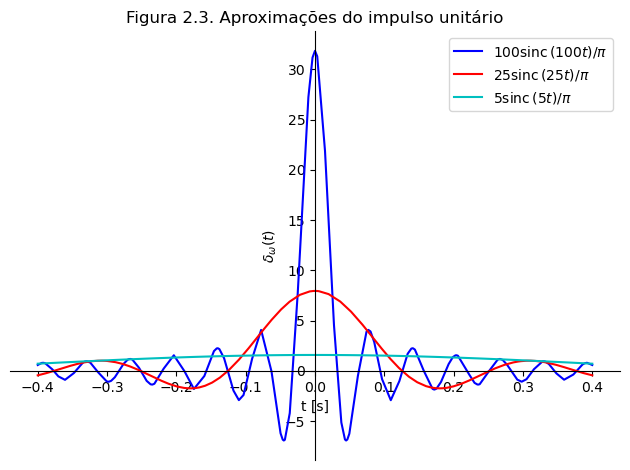

In [13]:
t = sym.Symbol('t')
s1 = (100/pi)*sym.sinc(100*t)
s2 = (25/pi)*sym.sinc(25*t)
s3 = (5/pi)*sym.sinc(5*t)
p = sym.plot(s1, s2, s3, (t, -0.4, 0.4), title='Figura 2.3. Aproximações do impulso unitário',\
             xlabel='t [s]', ylabel='$\delta_\omega(t)$', legend=True, show=False, adaptative = False,\
             nb_of_points=5000)

p[0].line_color = 'b'
p[1].line_color = 'r'
p[2].line_color = 'c'
p.show()

O impulso, portanto, pode ser interpretado como um indicador da ocorrência de uma divergência em uma determinada operação matemática, resultado de um processo de passagem ao limite para $\pm \infty$. Entretanto, para ser da forma impulsiva, a referida divergência deve ocorrer de maneira especial, qual seja, mantendo o valor da sua integral igual a um. Lembrando uma integral conhecida, temos
$$
\begin{aligned}
\int_{-\infty}^{\infty} \delta_w(t) d t & =\left(\frac{w}{\pi}\right) \int_{-\infty}^{\infty} \operatorname{sinc}(w t) d t \\
& =\int_{-\infty}^{\infty} \operatorname{sinc}(\pi \xi) d \xi=1
\end{aligned}
$$


In [14]:
z = sym.Symbol('z')
integrate(sym.sinc(pi*z),(z,-oo,oo))

1

que é independente do valor de $w>0$ e atesta que $\delta(t)=\lim _{w \rightarrow \infty} \delta_w(t)$. Como ficará claro no decorrer deste curso, o impulso unitário tem um papel central no estudo de sinais e sistemas. Talvez isso se deva ao fato de que a igualdade
$$
\int_{-\infty}^{\infty} f(t) \delta(t-\tau) d t=f(\tau)
$$
seja verdadeira para toda função contínua com domínio em $\mathbb{R}$. O impulso permite individualizar o valor de uma função contínua em qualquer instante $\tau \in \mathbb{R}$ do seu domínio. Como $\delta(t-\tau)=0$ para todo $t \neq \tau$, a verificação da veracidade da equação acima é imediata. 

Com o impulso podemos também construir funções mais elaboradas, como por exemplo
$$
v(t)=\int_{-\infty}^t \delta(\xi) d \xi
$$
pois a integral acima, levando em conta as propriedades do impulso), é nula para todo $t<0$ e é igual a 1 para todo $t \geq 0$. As manipulações algébricas com o impulso requerem certa atenção e cautela, sobretudo quando envolvem diferenciação em relação ao tempo.

Por fim, desejamos enfatizar que apresentamos as mais variadas propriedades dos sinais a tempo contínuo de forma bastante genérica. Neste sentido, consideramos $\mathbb{R}$ o seu domínio e $\mathbb{C}$ o seu conjunto imagem. O tratamento no domínio complexo e não real, ao contrário do que se possa imaginar, simplifica as manipulações matemáticas, sobretudo aquelas que envolvem as funções trigonométricas seno e cosseno. 

Esta afirmação ficará mais evidente no decorrer do texto. Para o tratamento exclusivo de sinais com imagem real a única modificação requerida é a substituição do conjugado de um sinal por ele próprio.


#### 2.2.1 Sinais a Tempo Discreto
Os sinais a tempo discreto são aqueles com domínio $\mathbb{Z}$ e com imagem em $\mathbb{R}$ ou $\mathbb{C}$. Vamos seguir exibindo resultados similares àqueles que apresentamos na seção anterior. Em larga medida, quase tudo pode ser refeito, mas *com um ferramental matemático um pouco diverso*. É preciso alertar que, em geral, calcular somas é mais trabalhoso e mais complicado do que calcular integrais.

**Definição 2.4 (Produto escalar)** O produto escalar de dois sinais $f(k)$ e $g(k)$ com o mesmo domínio $\mathbb{Z}$ e imagem $\mathbb{C}$ é um número complexo dado por
$$
\langle f, g\rangle=\sum_{k=-\infty}^{\infty} f(k) g(k)^*
$$
Assim definido, o produto escalar satisfaz os axiomas da simetria (conjugada), da distributividade, da homogeneidade e da positividade. Em consequência, a norma induzida é então dada por
$$
\|f\|=\sqrt{\langle f, f\rangle}=\sqrt{\sum_{k=-\infty}^{\infty}|f(k)|^2}
$$
e é importante ressaltar a possibilidade da soma indicada divergir. 

A norma de um sinal constante no tempo é $+\infty$. Para que a sua norma seja finita é necessário (mas não suficiente) que $|f(k)| \rightarrow 0$ quando $|k| \rightarrow \infty$. Podemos então concluir que todo sinal periódico tem norma infinita. Uma outra medida do tamanho de um sinal é dada em seguida.

**Definiçāo 2.5 (Valor eficaz)** O valor eficaz de um sinal $f(k)$ com domínio $\mathbb{Z}$ e imagem $\mathbb{C}$ é um número real não negativo dado por
$$
\|f\|_{e f}=\sqrt{\lim _{m \rightarrow \infty} \frac{1}{2 m+1} \sum_{k=-m}^m|f(k)|^2}
$$
Como o intervalo a tempo discreto $[-m, m]$ tem $2 m+1$ elementos, o valor eficaz de um sinal a tempo discreto tem também a simples interpretação de valor médio do seu módulo. Desta forma, para um sinal limitado no tempo por uma constante $\alpha$, obtém-se $\|f\|_{e f} \leq \alpha$. 

O valor eficaz de um sinal constante no tempo é igual ao módulo desta constante. 

O valor eficaz de um sinal periódico é igual ao valor eficaz calculado em apenas um período. De fato, considerando a definição acima com a mudança de variável $m = nN_0 - 1$, onde $N_0 \in \mathbb{N}$, é o período fundamental, temos
$$
\begin{aligned}
\|f\|_{e f}^2 & =\lim _{n \rightarrow \infty} \frac{1}{(2nN_0-1)} \sum_{k=-nN_0 +1}^{nN_0 - 1} |f(k)|^2 \\
& = \lim _{n \rightarrow \infty} \frac{1}{(2nN_0 - 1)}\left( 2n \sum_{k=0}^{N_0 - 1} |f(k)|^2 - |f(0)|^2 \right) \\
& =\frac{1}{N_0} \sum_{k=0}^{N_0 - 1}|f(k)|^2
\end{aligned}
$$

Como já foi possível notar, para manipular sinais a tempo discreto devemos ter bastante destreza com séries, inclusive envolvendo números complexos. Nesta direção, um dos resultados mais básicos entre os mais importantes é dado no seguinte lema. Ele torna explícita a condição de convergência da soma dos elementos de uma progressão geométrica com razão complexa.

**Lema 2.1** Considere $1 \neq z \in \mathbb{C}$ e $1 \leq i \in \mathbb{N}.$

A igualdade
$$
\sum_{k=0}^{i-1} z^k=\frac{1-z^i}{1-z}
$$
é verdadeira. 

Além disso, $\sum_{k=0}^{\infty} z^k=1 /(1-z)$ converge se e somente se $|z|<1$.


Prova: A prova é simples e bastante conhecida. Definido $S=1+z+\cdots+z^{(i-1)}$, então a multiplicação por $z$ leva a $z S=z+z^2+\cdots+z^i$. A subtração permite calcular $(1-z) S=1-z^i$, que fornece o resultado, pois $z \neq 1$. 

O cálculo do limite para $i \rightarrow \infty$ pode ser feito desde que $\lim _{i \rightarrow \infty} z^i$ exista. Como $\left|z^i\right|=|z|^i$, isso é assegurado se e apenas se $|z|<1$. Neste caso, o referido limite é nulo e a igualdade desejada é obtida. $\blacksquare$


A sequência de números complexos
$$
1, z, z^2, z^3, \cdots, z^{(i-1)}
$$

ao ser vista como uma progressão geométrica com razão $z \in \mathbb{C}$ permite afirmar que o Lema 2.1 generaliza para o campo complexo, um resultado já bastante conhecido para sequências reais. 

Os exemplos resolvidos em seguida ilustram os diversos aspectos das duas últimas definições no contexto de sinais a tempo discreto. Em particular, eles são importantes para indicar como as diversas somas que aparecem nas mencionadas definições são calculadas com auxílio do Lema 2.1. 

A estratégia consiste em utilizar a fórmula de Euler para converter funções trigonométricas em exponenciais complexas. Assim procedendo, somas de funções trigonométricas se convertem em somas de progressões geométricas que são manipuladas sem dificuldade. Entretanto, é preciso ficar alerta para aos limites da soma no Lema 2.1 (inicia em $k=0$ e termina em $k=i-1$, envolvendo portanto $i \in \mathbb{N}$ elementos).

Por outro lado, o resultado do Lema 2.1 pode ser manipulado sem qualquer problema desde que se observe o seu domínio de validade. Assim sendo, derivando em relação a $z$ ambos os lados da soma infinita de potências, obtemos uma nova igualdade
$$
\sum_{k=0}^{\infty} k z^k=\frac{z}{(1-z)^2}
$$
que é válida para todo $z \in \mathbb{C}$ tais que $|z|<1$. Este tipo de manipulação algébrica permite obter várias relações úteis, sobretudo no âmbito de sinais a tempo discreto.




In [15]:
z = sym.Symbol('z')
k = sym.Symbol('k')
expr = k*z**k
s = Sum(expr, (k, 0, oo))
s.doit()

Piecewise((z/(1 - z)**2, Abs(z) < 1), (Sum(k*z**k, (k, 0, oo)), True))

**Exemplo 2.9** Sejam os sinais $f(t)$ e $g(t)$ a tempo contínuo, considerados no Exemplo 2.4 e $T>0$ um escalar dado. Define-se o sinal a tempo discreto $s(k)=f(k T)=e^{\alpha T k}$ com domínio $\mathbb{Z}$ e imagem $\mathbb{R}_{+}$. Sua norma sempre é $+\infty$ para qualquer valor de $\alpha \in \mathbb{R}$. Seu valor eficaz é $+\infty$ para todo $\alpha \neq 0$ e é igual a $\|f\|_{e f}=1$ para $\alpha=0$. 

Note que o sinal $h(k)=g(k T)=e^{(\alpha+j \beta) T k}$ com domínio $\mathbb{Z}$ e imagem $\mathbb{C}$ é tal que $|h(k)|=s(k)=|s(k)|$ para todo $k \in \mathbb{Z}$. Assim sendo, a norma e o valor eficaz de $s(k)$ e de $h(k)$ coincidem. A norma e o valor eficaz de $h(k)$ nāo dependem de $\beta \in \mathbb{R}$.


**Exemplo 2.10** Considere o sinal senoidal $f(t)$ já estudado no Exemplo 2.5 e $T>$ 0 dado. Definimos o seguinte sinal a tempo discreto, resultante de uma operação de amostragem periódica, como sendo $s(k)=f(k T)=a$ sen $(\omega T k)$ com domínio $\mathbb{Z}$ e contradomínio $\mathfrak{C} \subset [-a, a] \subset \mathbb{R}$, em que $a>0$ e $\theta=\omega T \in(0, \pi)$. 

Em primeiro lugar, desejamos saber se este sinal é periódico. Devemos determinar o menor valor de $N_0>0$ tal que $f(k)=f\left(k+N_0\right)$ para todo $k \in \mathbb{Z}$ e $k+N_0 \in \mathbb{Z}$. Desenvolvendo o lado direito da igualdade $\operatorname{sen}(\theta k)=$ $\operatorname{sen}\left(\theta\left(k+N_0\right)\right)$, verificamos que ela é satisfeita se e apenas se $\cos \left(\theta N_0\right)=1$, ou seja $N_0=q(2 \pi / \theta)$ para algum $q \in \mathbb{Z}$. Como $N_0$ tem que ser um número natural, concluímos que $s(k)$ é um sinal periódico desde que a relaçāo $2 \pi / \theta$ seja um número racional. 

Sendo ou nāo periódico, vamos fazer os cálculos sem levar em conta esta informaçāo. Lembrando que a funçāo cosseno é par, temos 

$$
\begin{aligned}
\sum_{k=-m}^m \operatorname{sen}^2(\theta k) & =\frac{1}{2} \sum_{k=-m}^m(1-\cos (2 \theta k)) \\
& =\frac{2 m+1}{2}-\frac{1}{2} \sum_{k=-m}^m \cos (2 \theta k) \\
& =\frac{2 m+1}{2}-\frac{1}{2}\left(1+2 \sum_{k=1}^m \cos (2 \theta k)\right)
\end{aligned}
$$
Resta determinar a soma das funções cosseno. 

Aplicando-se o Lema 2.1 e após algumas manipulações algébricas, temos
$$
\begin{aligned}
1+2 \sum_{k=1}^m \cos (2 \theta k) & =1+\sum_{k=1}^m\left(e^{j 2 \theta k}+e^{-j 2 \theta k}\right) \\
& =\frac{\cos (2 \theta m)-\cos (2 \theta(m+1))}{1-\cos (2 \theta)} \\
& \leq \frac{2}{1-\cos (2 \theta)}
\end{aligned}
$$


Os cálculos anteriores indicam que $\|s\|=+\infty$. 

Por outro lado, temos que $\|s\|_{e f}=a / \sqrt{2}$, que é exatamente igual ao valor eficaz do sinal a tempo contínuo estudado no Exemplo 2.5. 

Os casos extremos caracterizados pelos ângulos $\theta=0$ ou $\theta=\pi$ geram sinais nulos, ou seja, $s(k)=0$ para todo $k \in \mathbb{Z}$, o que leva obviamente a $\|s\|=\|s\|_{e f}=0$.

**Lema 2.2** $$1 + 2^2 + 3^2 + \cdots + n^2 = \frac{n(n+1)(2n + 1)}{6}$$.

Prova: esta demonstração é um exercício recorrente do princípio de indução finita [Elon Lages Lima Análise Real, Volume 1 Funções de uma Variável IMPA (2006)]. Aqui, vamos fazê-la diretamente. 


Inicialmente, vamos observar a conhecida identidade
$$
(n+1)^3=n^3 +3n^2 + 3n+1
$$

Atribuindo-se os valores de $n=0,1,2, \ldots, n$, temos
$$
\begin{array}{llll}
n &=0:(0+1)^3&=1^3 & =0^3+3.0^2+3.0+1 \\
n &=1:(1+1)^3&=2^3 & =1^3+3.1^2+3.1+1 \\
n &=2:(2+1)^3&=3^3 & =2^3+3.2^2+3.2+1 \\
n &=3:(3+1)^3&=4^3 & =3^3+3.3^2+3.3+1 \\
n &=4:(4+1)^3&=5^3 & =4^3+3.4^2+3.4+1 \\
&\vdots &\vdots &\vdots\\
n &=n:(n+1)^3&=(n+1)^3 &=n^3+3 n^2+3 n+1
\end{array}
$$
Somando as identidades acima, 
$$
1^3+2^3+3^3+\ldots+(n+1)^3= 1^3+2^3+3^3+\ldots+n^3 +  3\left(1^2+2^2+3^2+\ldots+n^2\right)+3(1+2+3+\ldots+n)+(n+1)
$$

Simplificando a expressão acima e denotando-se $1^2+2^2+3^2+\ldots+n^2 = S$, temos que

$$
(n+1)^3 = 3S + 3\frac{n(n+1)}{2} + n + 1 
$$
De onde obtemos, 
$$
S = \frac{n(n+1)(2n+1)}{6} \qquad \square
$$

In [16]:
n = Symbol('n')
m = Symbol('m')
expr = m**2

s = Sum(expr, (m, 1, n))
factor(s.doit())


n*(n + 1)*(2*n + 1)/6

**Exemplo 2.11** Considere o sinal $f(t)$ a tempo contínuo, com período $T_0>0$, denominado dente de serra, estudado no Exemplo 2.6. Definimos o sinal periódico, a tempo discreto, cujo primeiro período $|k| \leq r \in \mathbb{N}$ é dado por $s(k)=f(h k)=a h k,$ com $a>0$. O valor de $h>0$ pode ser escolhido de forma a fazer com que o sinal $s(k)$ seja periódico com período $N_0 = T_0/2h +1 \in \mathbb{N}$.

Assim sendo, a sua norma é $+\infty$ e o seu valor eficaz é determinado por uma relação equivalente a 

$$
\|s\|_{e f}^2 =\frac{1}{N_0} \sum_{k=0}^{N_0 - 1}|f(k)|^2,
$$
isto é,

$$
\begin{aligned}
\|s\|_{e f}^2 & =\frac{(a h)^2}{N_0} \sum_{k=0}^{N_0 - 1} k^2 \\
& = \frac{(a h)^2}{N_0} \frac{(N_0 - 1)N_0(2N_0 -1)}{6} \\
& = \frac{a^2 h^2}{6}\frac{T_0}{2h}\left(\frac{T_0 }{h} +1 \right)
\end{aligned}
$$
onde utilizamos o Lema 2.2. Assim,
$$
\|s\|_{e f}=\frac{a T_0}{2 \sqrt{3}} \sqrt{1+\frac{h}{T_0}}
$$
Comparando com o caso a tempo contínuo nota-se que o valor eficaz do sinal discreto $s(k)$ é sempre maior que o valor eficaz de $f(t)$. Esses valores tornam-se arbitrariamente próximos desde que o passo de discretização $h$ satisfaça $h \ll T_0 $.

No caso de sinais a tempo discreto, também é importante considerar o cálculo de normas para sinais obtidos como resultado da combinação linear de um certo número de sinais elementares $f_1(k), \cdots, f_m(k)$, ou seja,
$$
g(k)=\sum_{i=1}^m c_i f_i(k)
$$
em que $c_i \in \mathbb{C}$ para todo $i=1, \cdots, m$ são escalares conhecidos. Aplicando a definição de norma e fazendo uso da sua distributividade, obtemos
$$
\|g\|^2=\sum_{i=1}^m \sum_{n=1}^m c_i c_j^*\left\langle f_i, f_n\right\rangle
$$
o que coloca em evidência que a igualdade
$$
\|g\|^2=\sum_{i=1}^m\left|c_i\right|^2\left\|f_i\right\|^2
$$
se verifica para sinais elementares que satisfaçam as relações
$$
\left\langle f_i, f_n\right\rangle=\sum_{k=-\infty}^{\infty} f_i(k) f_n(k)^*=0
$$

para todo $i \neq n=1, \cdots, m$. 

Se estes sinais elementares forem ortonormais, então a norma quadrática se reduz a $\|g\|^2=\left|c_1\right|^2+\cdots+\left|c_m\right|^2$. Podemos interpretar um conjunto destes sinais elementares como uma base que permite escrever outros sinais a partir de combinações lineares específicas. A determinação de conjuntos de sinais ortonormais é um tema de grande relevância que será abordado mais adiante. A seguinte definição, embora idêntica ao caso a tempo contínuo, será incluída para tornar mais fácil a leitura.

**Definição 2.6** (Sinal par e sinal ímpar) Um sinal $f(k)$ com dominio $\mathbb{Z}$ é denominado **par** se $f(k)=f(-k)$ para todo $k \in \mathbb{Z}$ e é denominado **ímpar** se $f(k)=-f(-k)$ para todo $k \in \mathbb{Z}$.

É claro que um sinal qualquer pode não ser par nem ímpar, mas qualquer sinal pode ser decomposto na forma $f(k)=f_p(k)+f_i(k)$, em que $f_p(k)$ é a sua componente par e $f_i(k)$ é a sua componente ímpar, que são dadas por
$$
\begin{aligned}
f_p(k) & =\frac{1}{2}(f(k)+f(-k)) \\
f_i(k) & =\frac{1}{2}(f(k)-f(-k))
\end{aligned}
$$

A partir da simples aplicação da definição conclui-se que, de fato, o sinal $f_p(k)$ é par e que o sinal $f_i(k)$ é ímpar. É também possível verificar que para qualquer sinal as suas componentes par e ímpar são ortogonais. Esta importante propriedade decorre do cálculo do produto escalar $\left\langle f_p, f_i\right\rangle$ exatamente como foi feito no caso a tempo contínuo. Em muitas situaçōes é útil lembrar que, para qualquer sinal $f(k)$, o sinal produto a ele associado $s(k)=f(k) f(-k)$ é sempre um sinal par. Observe que o mesmo não ocorre com o sinal resultante da divisão $f(k) / f(-k)$, ainda que esta operação possa ser realizada para todo $k \in \mathbb{Z}$.

**Exemplo 2.12** Seja o sinal a tempo contínuo $f(t)=e^{-|t-1|}$ com domínio $t \in \mathbb{R}$. A partir dele construímos o sinal a tempo discreto $s(k)=f(k h)$ com domínio $k \in \mathbb{Z}$. 


A Figura 2.4 mostra as componentes par e ímpar de cada sinal no intervalo de tempo $t \in[-5,5]$ e $k \in[-10,10]$. A fim de representar ambos os sinais na mesma abscissa temporal, para o sinal a tempo discreto consideramos $t=h k $ com $k \in[-10,10]$ e $h=0,5$. 

Pode-se verificar numericamente que, em ambos os casos, as componentes par e ímpar são ortogonais.

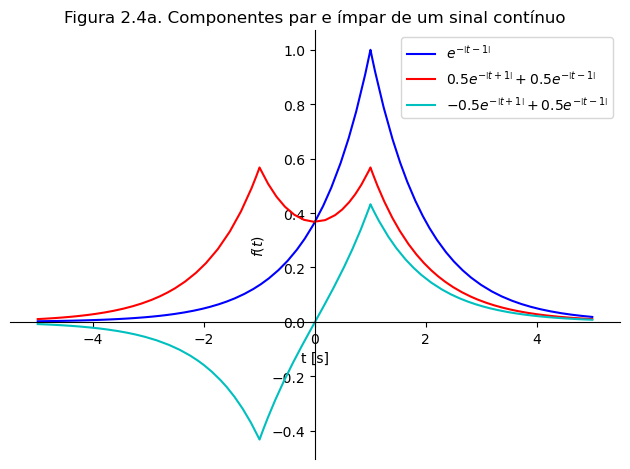

In [17]:
t = sym.Symbol('t')
s1 = exp(-abs(t-1))
s2 = 0.5*(exp(-abs(t-1)) + exp(-abs(-t-1)))
s3 = 0.5*(exp(-abs(t-1)) - exp(-abs(-t-1)))
p = sym.plot(s1, s2, s3, (t, -5, 5), title='Figura 2.4a. Componentes par e ímpar de um sinal contínuo',\
             xlabel='t [s]', legend=True, show = False)

p[0].line_color = 'b'
p[1].line_color = 'r'
p[2].line_color = 'c'
p.show()

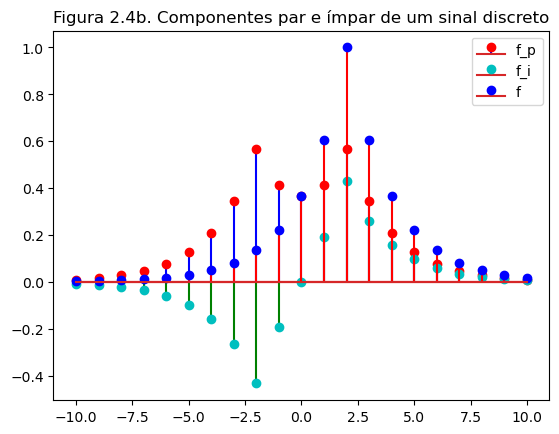

In [18]:
z = []
z1 = []
z2 = []
for k in range(-10,11):
    z.append(k)
    z1.append(exp(-abs(k*0.5-1)))
    z2.append(exp(-abs(-k*0.5-1)))
s1 = z1
s2 = [(a + b)*0.5 for a, b in zip(z1, z2)]
s3 = [(a - b)*0.5 for a, b in zip(z1, z2)]

plt.stem(z, s2, 'b', markerfmt='ro', label='f_p')
plt.stem(z, s3, 'g', markerfmt='co', label='f_i')
plt.stem(z, s1, 'r', markerfmt='bo', label='f')
plt.legend()
plt.title('Figura 2.4b. Componentes par e ímpar de um sinal discreto')
plt.show()

**Exemplo 2.13** (Energia e Potência) De maneira similar aos sinais a tempo contínuo, para os sinais a tempo discreto a quantidade $E=\|f\|^2$ quando finita classifica-o como um **sinal de energia**. Por outro lado, se $P=\|f\|_{ef}^2$ for finita ele é classificado como um **sinal de potência**. Eventuais interpretaçōes físicas dessas quantidades sāo feitas de maneira aproximada via amostragem.

No estudo de sinais a tempo discreto também existem algumas funções que são especiais e que, portanto, merecem ser apresentadas de maneira mais detalhada. Todas elas são definidas no domínio $k \in \mathbb{Z}$ e têm imagem em $\mathbb{R}$.

- **Degrau unitário**: Trata-se de uma das funçōes mais importantes no estudo de sinais. Ela é definida por
$$
v(k)= \begin{cases}1, & k \geq 0 \\ 0, & k<0\end{cases}
$$
e observe que $v(0)=1$.
- **Retângulo unitário**: Trata-se de uma função usada para selecionar partes simétricas (em relaçāo à origem) de sinais. Ela é definida na forma
$$
\vartheta(k)= \begin{cases}1, & |k| \leq n \\ 0, & |k|>n\end{cases}
$$
sendo $1 \leq n \in \mathbb{N}$. Ela pode ser escrita como uma composição de dois degraus unitários deslocados, ou seja, $\vartheta(k)=v(k+n)-v(k-n-1)$. É claro que a sua largura pode ser alterada segundo o valor de $n \in \mathbb{N}$ escolhido.

Por fim, desejamos introduzir o chamado impulso unitário, que tem importância singular no estudo de sinais (e de sistemas) a tempo discreto. Como é usual, adotamos a mesma notaçāo $\delta(k)$, mas *se trata de um ente matemático muito diferente do impulso unitário a tempo contínuo* e é definido por

- **impulso unitário**:
$$
\delta(k)= \begin{cases}1, & k=0 \\ 0, & k \neq 0\end{cases}
$$
Em algumas situações é conveniente identificar $\delta(k)=0^k$, tomando-se $0^0=1$, por convenção. 

A seguinte igualdade se estabelece

$$
\sum_{k=-\infty}^{\infty} f(k) \delta(k-n)=f(n)
$$
a qual seleciona, para cada $n \in \mathbb{Z}$ dado, o valor da função $f(k)$ no instante $k=n \in \mathbb{Z}$. Como $\delta(k-n)=0$ para todo $k \neq n$ e $\delta(k-n)=1$ para $k=n$, verifica-se a validade da relação acima de maneira trivial. 

Funções elementares podem ser escritas com o impulso unitário. O degrau unitário é uma delas
$$
v(k)=\sum_{n=-\infty}^k \delta(n)
$$
como pode ser verificado sem dificuldades. O impulso unitário em tempo discreto não tem as singularidades do seu homônimo $\delta(t)$ em tempo contínuo. São entidades matemáticas diversas. Como já foi dito, ambos têm grande utilidade não só no estudo de sinais, mas também no estudo de sistemas dinâmicos.

Vale ressaltar que tudo foi feito para sinais com imagem em $\mathbb{C}$. Os mesmos resultados para o caso específico de sinais com imagem em $\mathbb{R}$ decorrem de forma imediata. Trabalhar diretamente com o conjunto $\mathbb{C}$ facilita os cálculos, mas requer uma certa destreza com números complexos e funçōes de variável complexa.



## 3. Sistemas

De forma bastante genérica, um **sistema** é *todo dispositivo que processa sinais*. Um sistema pode ser representado na forma de um diagrama de blocos como ilustrado na Figura 2.5. 

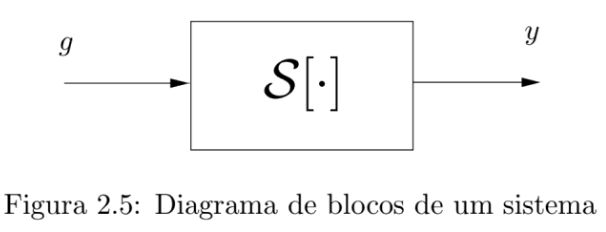

Ele atua no sinal $g$ presente na sua entrada e fornece como resultado o sinal $y$ que disponibiliza na sua saída. Nosso propósito é estudar os **sistemas** denominados **dinâmicos** *cuja saída depende não só da entrada em um determinado instante, mas eventualmente de todo o seu passado*.

Um sistema é completamente caracterizado pelo operador $\mathcal{S}[\cdot]$, que nada mais é que uma relação matemática que permite determinar o sinal de saída $y$ como resposta ao sinal de entrada $g$, ou seja,
$$
y=\mathcal{S}[g]
$$
Para ficar mais claro, imaginemos um sistema a tempo contínuo composto por um resistor com resistência $R[\Omega]$. Tomamos como entrada o sinal de tensão $g$ em $[V]$ colocado nos seus terminais e como saída o sinal de corrente resultante em $[A]$. A lei de Ohm imediatamente fornece 

$$S[g]=g / R$$

Trata-se de um **sistema** denominado **algébrico**, pois a *sua saída, em cada instante de tempo, depende da entrada apenas naquele mesmo instante*. 

Se o resistor for trocado por um indutor com indutância $L[H]$ o novo sistema é caracterizado pelo operador
$$
\mathcal{S}[g]=\frac{1}{L} \int_{-\infty}^t g(\tau) d \tau
$$
onde se assume que no início do tempo $t=-\infty$ o sistema estava isolado, inoperante. Nota-se que agora o valor da saida $y(t)$ em um determinado instante $t \in \mathbb{R}$ depende de toda a história da entrada $\{g(\tau), \forall \tau \leq t\}$ até aquele instante. 

Assim como os sinais, existem **sistemas a tempo contínuo** e **sistemas a tempo discreto**. Os primeiros processam sinais com domínio $t \in \mathbb{R}$, enquanto que os últimos processam sinais com domínio $k \in \mathbb{Z}$. Independentemente desta característica importante, os sistemas são classificados segundo as seguintes classes que colocam em evidência as suas características mais relevantes:


- **Sistemas lineares**: sāo aqueles que respeitam o **Princípio da Superposiçāo**. Se $y_i$ é a saída correspondente à entrada $g_i$ para todo $i=1,2, \cdots, m$ então $y=\sum_i \alpha_i y_i$ é a saída correspondente à entrada $g=\sum_i \alpha_i g_i$. Assim sendo, para todas entradas $g_i$ e escalares $\alpha_i$ com $i=1,2, \cdots, m$ temos
$$
\mathcal{S}\left[\sum_{i=1}^m \alpha_i g_i\right]=\sum_{i=1}^m \alpha_i \mathcal{S}\left[g_i\right]
$$
o que torna evidente que a linearidade do sistema preserva na saída a mesma combinação linear da entrada.

- **Sistemas invariantes no tempo**: são assim chamados quando um atraso arbitrário na entrada implicar o mesmo atraso na saída. Sendo $g(t)$ e $y(t)$ sinais de entrada e de saída que, portanto, satisfazem a relação $y=\mathcal{S}[g]$, se definirmos os sinais atrasados $g_\tau(t)=g(t-\tau)$ e $y_\tau(t)=y(t-\tau)$, então
$$
y_\tau=\mathcal{S}\left[g_\tau\right]
$$
Para esta classe de sistemas podemos arbitrar, sem perda alguma, o instante inicial $t_0=0$ em que sua resposta começa a ser calculada.
- **Sistemas causais**: causalidade é um importante conceito que também é bastante intuitivo. A sua saída $y(t)$ depende apenas da entrada $g(\tau)$ para todo $\tau \leq t$. Ou seja, um sistema causal só pode ser influenciado pelo passado e pelo presente, jamais pelo futuro. *Apenas os sistemas causais podem ser realizados*.

Neste curso trataremos sobretudo os **sistemas lineares invariantes no tempo**, identificados pela sigla (**LIT**), e causais. Esse é, sem dúvida, o caso mais importante não só pelas suas implicações teóricas, mas também por sua ampla utilização prática. A seguir, tendo em vista a importância e as particularidades de cada um deles, passamos a estudar separadamente os sistemas LIT a tempo contínuo e a tempo discreto.


### 3.1 Sistemas a Tempo Contínuo
A análise de sistemas a tempo contínuo tem como base a chamada operação de **convolução** de dois sinais. Sejam dois sinais $g(t)$ e $h(t)$ com domínio $\mathbb{R}$ e imagem $\mathbb{R}$. A convolução de $g$ por $h$, denotada por $g * h$, tem como resultante um outro sinal $f(t)$ com mesmo domínio e mesmo conjunto imagem, dado por
$$
f(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau
$$
Esta operação é associativa, distributiva e comutativa. 

Em particular, esta última propriedade decorre da mudança da variável de integração. De fato, definindo a nova variável $\xi=t-\tau$, vem
$$
\begin{aligned}
g * h & =\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau \\
& =\int_{-\infty}^{\infty} g(t-\xi) h(\xi) d \xi \\
& =h * g
\end{aligned}
$$

que é o resultado desejado. Assim sendo, não há necessidade de se preocupar com qual sinal deve ser aquele que aparece atrasado no cálculo da integral, pois ambas as possibilidades fornecem o mesmo resultado. 

Um caso particular tem importância singular. Trata-se da convolução de um sinal $g(t)$ com o impulso unitário $\delta(t)$, que resulta em
$$
g * \delta=\int_{-\infty}^{\infty} g(\tau) \delta(t-\tau) d \tau=g(t)
$$

Isto indica que **o impulso é o elemento neutro da operação de convolução**, tendo em vista que a convolução de qualquer sinal com o impulso unitário fornece o próprio sinal. 

Para se conhecer tudo a respeito de um sistema LIT representado pelo operador $\mathcal{S}[\cdot]$, basta conhecer a sua resposta ao impulso unitário denotada por
$$
h=\mathcal{S}[\delta]
$$

Isto quer dizer que todas as respostas possíveis sāo obtidas a partir desta resposta fundamental, como fica demonstrado no próximo teorema.

**Teorema 2.1** Para qualquer sinal de entrada $g(t)$ dado, o sinal de saída $y(t)$ de um sistema LIT definido por $y=\mathcal{S}[g]$ é dado por
$$
y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau
$$
em que $h(t)$ é a sua resposta ao impulso unitário.

Prova: Escrevendo o sinal de entrada $g(t)$ como $g * \delta=\int_{-\infty}^{\infty} g(\tau) \delta(t-\tau) d \tau=g(t)$, assumindo que o sistema é LIT e calculando a saída correspondente, tem-se
$$
\begin{aligned}
y(t) & =\mathcal{S}\left[\int_{-\infty}^{\infty} g(\tau) \delta(t-\tau) d \tau\right] \\
& =\int_{-\infty}^{\infty} g(\tau) \mathcal{S}[\delta(t-\tau)] d \tau \\
& =\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau
\end{aligned}
$$
ou seja, $y=g * h$ como se desejava demonstrar. $\square$

É importante ficar claro que a linearidade do sistema foi utilizada na primeira igualdade para passar o operador $\mathcal{S}[\cdot]$ para dentro da integral e para retirar do seu interior a constante $g(\tau)$, tendo em vista que ele se aplica à variável $t \in \mathbb{R}$. Finalmente, como se trata de um sistema invariante no tempo, a terceira igualdade é obtida. O teorema foi provado sem que a causalidade fosse utilizada. 

De fato, como evidencia o próximo lema, a causalidade de um sistema se reflete na sua resposta ao impulso.

**Lema 2.3** Um sistema LIT definido por $y=\mathcal{S}[g]$ é causal quando a sua resposta ao impulso for tal que $h(t)=0$, $\forall t<0$.

Prova: Como a fórmula $y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau$ é válida, calculando-a com $h(t)=0$ para todo $t<0$, obtemos
$$
y(t)=\int_{-\infty}^t g(\tau) h(t-\tau) d \tau
$$

desde que 

$$
y(t)=\int_{t}^{+ \infty} g(\tau) h(t-\tau) d \tau = 0
$$

o que torna aparente que, apenas sob esta condição, a saída $y(t)$ depende da entrada $g(\tau)$ para todo $\tau \in(-\infty, t]$, provando assim o lema proposto. $\square$

Um caso especial, bastante frequente, ocorre quando o sinal de entrada for nulo para todo $t<0$. A aplicação do Lema 2.3 leva imediatamente a
 $$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau, & t \geq 0 \\
0, & t<0
\end{array}\right.
$$
Como se trata de um sistema LIT causal o sinal de saída permanece nulo para todo $t<0$, pois o sinal de entrada é nulo neste mesmo intervalo de tempo. Este resultado é utilizado na resoluçāo dos exemplos discutidos em seguida, nos quais consideramos alguns sinais de entrada básicos, de grande ocorrência e utilidade no estudo de sinais e sistemas.

**Exemplo 2.14** (Resposta ao degrau unitário) Assumindo que o sistema seja LIT e considerando o sinal de entrada $g(t)=v(t)$ obtemos, pela aplicação direta de $y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau$, a resposta correspondente na forma
$$
\begin{aligned}
y(t) & =\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau \\
& =\int_0^{\infty} h(t-\tau) d \tau \\
& =\int_{-\infty}^t h(\xi) d \xi
\end{aligned}
$$

onde realizamos a mudança de variável $\xi=t-\tau$ para obter a última igualdade. 

Se o sistema além de LIT for causal, teremos como resposta ao degrau unitário
$$
y(t)=\int_0^t h(\tau) d \tau
$$
para todo $t \geq 0$ e $y(t)=0$ para todo $t<0$. Desta forma, podemos concluir que a resposta ao degrau unitário é a integral da resposta ao impulso unitário.

**Exemplo 2.15** (Resposta ao sinal exponencial) O sinal de entrada é da seguinte forma $g(t)=e^{\lambda t}$ com $\lambda \in \mathbb{C}$. Este sinal tem domínio $\mathbb{R}$ e imagem $\mathbb{C}$. Assumindo que o sistema seja LIT, o resultado do Teorema 2.1 fornece
$$
\begin{aligned}
y(t) & =\int_{-\infty}^{\infty} e^{\lambda \tau} h(t-\tau) d \tau \\
& =\int_{-\infty}^{\infty} e^{\lambda(t-\xi)} h(\xi) d \xi \\
& =\left(\int_{-\infty}^{\infty} e^{-\lambda \xi} h(\xi) d \xi\right) e^{\lambda t}
\end{aligned}
$$

onde realizamos a mudança de variável $\xi=t-\tau$ para obter a segunda igualdade. 

Se o sistema em estudo também for causal, a sua reposta tem a forma mais simples
$$
y(t)=\left(\int_0^{\infty} e^{-\lambda \xi} h(\xi) d \xi\right) e^{\lambda t}
$$
válida para todo $t \in \mathbb{R}$. 

Nota-se que a quantidade entre parênteses só depende da resposta ao impulso do sistema em consideração e do parâmetro $\lambda \in \mathbb{C}$ que define o sinal de entrada. É uma constante em relação ao tempo que, ao ser denotada por $\hat{h}(\lambda)$, coloca em evidência que o sinal de saída é dado por $y(t)=\hat{h}(\lambda) e^{\lambda t}$, $\forall t \in \mathbb{R}$. 


Retomando $y=\mathcal{S}[g]$ obtemos, finalmente, a relação
$$
\mathcal{S}\left[e^{\lambda t}\right]=\hat{h}(\lambda) e^{\lambda t}
$$
que permite dizer que a funçāo exponencial $e^{\lambda t}, \forall t \in \mathbb{R}$, é uma autofunção e o escalar $\hat{h}(\lambda) \in \mathbb{C}$ é o respectivo autovalor do operador $\mathcal{S}[\cdot]$.  $\square$

<!---Para um sistema causal é importante analisarmos como podemos identificar, isto é, determinar a sua resposta ao impulso $h(t)$ com domínio em $\mathbb{R}_{+}$. Para isso, escolhemos uma entrada do tipo exponencial $g(t)=e^{\lambda t} v(t) \operatorname{com} \lambda \in \mathbb{C}$ e assumimos que a saída correspondente, que é do tipo $y(t)=y_0(t) v(t)$, seja conhecida. Reescrevendo 
$$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau, & t \geq 0 \\
0, & t<0
\end{array}\right.
$$
na forma alternativa
$$
y(t)=\int_0^t g(t-\tau) h(\tau) d \tau
$$
e substituindo os sinais que acabamos de descrever, vem
$$
\int_0^t e^{-\lambda \tau} h(\tau) d \tau=e^{-\lambda t} y_0(t) v(t), \forall t \in \mathbb{R}_{+}
$$

que é um equação integral que, ao ser resolvida, fornece $h(t)$ para todo $t \in \mathbb{R}_{+}$. Nota-se que a solução deste problema é obtida pela derivação em relação ao tempo dos dois membros desta igualdade, mas para isso é preciso saber derivar o degrau unitário que nem mesmo é uma função contínua em $t=0$. 

Como será visto mais adiante, isto pode ser feito a partir da generalização do conceito de derivada que resulta do estudo da Transformada de Fourier. Essas consideraçōes permitem concluir que $d v(t) / d t=\delta(t)$. 

Derivando $\int_0^t e^{-\lambda \tau} h(\tau) d \tau=e^{-\lambda t} y_0(t) v(t), \quad \forall t \in \mathbb{R}_{+}$ em relação ao tempo, com algumas manipulações algébricas, obtemos
$$
h(t)=\left(\dot{y}_0(t)-\lambda y_0(t)\right) v(t)+y_0(0) \delta(t)
$$
em que utilizamos a propriedade do impulso unitário $y_0(t) \delta(t)=y_0(0) \delta(t)$. Em geral, ocorre que $y_0(0)=0$, pois o sinal de entrada é nulo para todo $t<0$ e o sistema em estudo parte do repouso. Neste caso, mais frequente, o impulso que aparece em $h(t)$ é eliminado.--->

 **Exemplo 2.16** Um circuito RC série é alimentado por uma tensão $g(t)$. Se escolhermos a tensão no capacitor como sendo a saída de interesse $y(t)$, a sua resposta ao impulso é dada por $y(t)=0$ para todo $t<0 $ e
$$
h(t)=\left(1 / c_0\right) e^{-t / c_0}, \forall t \geq 0
$$
em que $c_0=R C[\mathrm{~s}]$ é a sua constante de tempo. Portanto, a dimensão física de $h(t)$ é $\left[\mathrm{s}^{-1}\right]$. Trata-se, claro, de um sistema LIT causal. Como já vimos, a sua resposta a um degrau de amplitude $V_0[\mathrm{~V}]$, isto é, $g(t)=V_0 v(t)$ pode ser determinada por mera integração, ou seja,
$$
\begin{aligned}
y(t) & =V_0\left(1 / c_0\right) \int_0^t e^{-\tau / c_0} d \tau \\
& =V_0\left(1-e^{-t / c_0}\right)[\mathrm{V}]
\end{aligned}
$$
para todo $t \geq 0$ e $y(t)=0$ para todo $t<0$. Como a entrada considerada é igual ao degrau unitário multiplicado por $V_0$, apenas multiplicamos a saída correspondente pela mesma constante. Isto é possível pois o sistema é linear.

**Exemplo 2.17** Se no exemplo anterior substituirmos o resistor por um indutor com indutancia $L[\mathrm{H}]$, a resposta ao impulso torna-se $y(t)=0$ para todo $t<0$ e
$$
h(t)=\omega_0 \operatorname{sen}\left(\omega_0 t\right), \forall t \geq 0
$$
em que $\omega_0=1 / \sqrt{L C}[\mathrm{rad} / \mathrm{s}]$ é a sua frequência natural de oscilaçāo. Portanto, a dimensāo física de $h(t)$ é $[\mathrm{rad} / \mathrm{s}]$. O sinal de entrada que desejamos considerar é $g(t)=\cos (\omega t) v(t)$. 

O sinal de saída correspondente é dado em 
$$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau & , \quad t \geq 0 \\
0 & , \quad t<0
\end{array}\right.
$$
isto é, $y(t)=0$ para todo $t<0 $ e
$$
\begin{aligned}
y(t) & =\omega_0 \int_0^t \cos (\omega \tau) \operatorname{sen}\left(\omega_0(t-\tau)\right) d \tau \\
& =\frac{\omega_0}{2} \int_0^t\left(\operatorname{sen}\left(\omega_0 t+\left(\omega-\omega_0\right) \tau\right)+\operatorname{sen}\left(\omega_0 t-\left(\omega+\omega_0\right) \tau\right)\right) d \tau \\
& =\frac{\omega_0^2}{\omega^2-\omega_0^2}\left(\cos \left(\omega_0 t\right)-\cos (\omega t)\right), \forall t \geq 0
\end{aligned}
$$
em que assumimos $\omega \neq \omega_0$. 

Para $\omega=\omega_0$ as contas podem ser refeitas para se obter
$$
y(t)=\frac{\omega_0}{2} t \operatorname{sen}\left(\omega_0 t\right), \forall t \geq 0
$$
e neste caso, um sinal de entrada limitado em um sistema com resposta ao impulso limitada produz um sinal de saída ilimitado. Este fenômeno é chamado de **ressonância** e ocorre quando a resposta ao impulso e o sinal entrada são sinais periódicos com a mesma frequência natural ou, equivalentemente, com períodos iguais. Este comportamento será estudado com maiores detalhes em seguida. $\square$

In [19]:
w = sym.Symbol('w')
w0 = sym.Symbol('w0')
t = sym.Symbol('t')
T = sym.Symbol('T')
simplify(integrate(w0*cos(w*T)*sin(w0*(t - T)),(T,0,t)))

Piecewise((t*w0*sin(t*w0)/2, (Eq(w, 0) | Eq(w, w0) | Eq(w, -w0)) & (Eq(w, w0) | Eq(w0, 0) | Eq(w, -w0))), (w0**2*cos(t*w)/(-w**2 + w0**2), Eq(w, w0) | Eq(w, -w0) | (Eq(w, 0) & Eq(w0, 0))), (w0**2*(-cos(t*w) + cos(t*w0))/(w**2 - w0**2), True))

Um conceito fundamental relativo aos sistemas é o de **estabilidade**. De maneira nāo muito rigorosa, sistemas estáveis tendem a atenuar os sinais de entrada, enquanto que os instáveis tendem a amplificá-los. Por este motivo, **instabilidade** é um indicador de sérios problemas, sobretudo em sistemas físicos que podem ser levados a transitar longe dos seus pontos normais de operação.

**Definição 2.7 (Estabilidade)** Um **sistema** é **estável** se a todo sinal de entrada limitado corresponder um sinal de saída limitado.

Como vimos anteriormente, a resposta ao impulso unitário define o comportamento de qualquer sistema LIT. Dessa forma, para esta classe, a definição acima deve ser traduzida em alguma característica particular da sua resposta ao impulso. Como mostra o próximo teorema, isto de fato ocorre.

**Lema 2.4** Um sistema LIT com resposta ao impulso $h(t)$ é estável se e apenas se
$$
M_h=\int_{-\infty}^{\infty}|h(\tau)| d \tau
$$
for um valor finito.


Prova: Inicialmente, assumimos que $M_h=\int_{-\infty}^{\infty}|h(\tau)| d \tau$ é satisfeita e que a entrada é limitada, isto é, $|g(t)| \leq M_g<\infty$ para todo $t \in \mathbb{R}$. Com a resposta correspondente a esta entrada dada por $y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau$, verificamos a partir de 
$$
\begin{aligned}
|y(t)| & =\left|\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau\right| \\
& \leq \int_{-\infty}^{\infty}|g(\tau)||h(t-\tau)| d \tau \\
& \leq M_g \int_{-\infty}^{\infty}|h(\xi)| d \xi=M_g M_h
\end{aligned}
$$
que ela é limitada para todo $t \in \mathbb{R}$ e assim concluímos que o sistema é estável. 

Inversamente, vamos calcular $y(0)$ para a entrada limitada $g(t)=1$ se $h(-t) \geq 0$ e $g(t)=-1$ se $h(-t) \leq 0$. Com a saída correspondente dada por $M_h=\int_{-\infty}^{\infty}|h(\tau)| d \tau$, temos
$$
\begin{aligned}
y(0) & =\int_{-\infty}^{\infty} g(\tau) h(-\tau) d \tau \\
& =\int_{-\infty}^{\infty}|h(-\tau)| d \tau \\
& =\int_{-\infty}^{\infty}|h(\xi)| d \xi=M_h
\end{aligned}
$$

e concluímos que a saída correspondente a esta entrada limitada será também limitada apenas se a constante $M_h$ for finita.

Para sistemas LIT causais a constante $M_h$ se simplifica para
$$
M_h=\int_0^{\infty}|h(\tau)| d \tau
$$
e fica claro que uma condição necessária (mas não suficiente) para que $M_h$ seja finita é que $\lim _{t \rightarrow+\infty}|h(t)|=0$. 

Uma condição suficiente para que isso ocorra é que existam constantes $\alpha>0$ e $\beta \geq 0$ tais que $|h(t)| \leq \beta e^{-\alpha t}$ para todo $t \in \mathbb{R}_{+}$, pois $M_h \leq \beta / \alpha$. Neste caso o sistema é dito **assintoticamente estável**. O gráfico do módulo da resposta ao impulso em função do tempo permite estimar esses parâmetros.

**Exemplo 2.18** Para um sistema LIT causal com resposta ao impulso da forma
$$
h(t)=\sum_{i=1}^n \theta_i e^{\lambda_i t}, \forall t \geq 0
$$
se $\operatorname{Re}\left(\lambda_i\right) \leq-\alpha<0$ para todo $i=1,2, \cdots, n$ verificamos imediatamente que com $\beta=\sum_{i=1}^n\left|\theta_i\right|$ a desigualdade $|h(t)| \leq \beta e^{-\alpha t}$ para todo $t \geq 0$ é verdadeira e a estabilidade assintótica é assegurada. Note que, se para algum $1 \leq i \leq n$ ocorrer $\operatorname{Re}\left(\lambda_i\right)>0,$ o sistema é instável. Neste contexto, o Exemplo 2.17 é emblemático. É claro que para aquele sistema tem-se $|h(t)| \leq \omega_0$ e $\alpha=0$. Ele não obedece a definição de estabilidade, pois a constante $M_h=+\infty$, isto é, torna-se ilimitada. Por este motivo, e levando em consideração que a condiçāo do Lema 2.3 é necessária e suficiente, existe um sinal de entrada limitado cuja saída correspondente é ilimitada.

### 3.2 Sistemas a Tempo Discreto
Como ocorreu com o estudo de sinais, o de sistemas a tempo discreto é bastante parecido com o que foi feito para os sistemas a tempo contínuo. Mesmo assim, mais uma vez, vale a pena colocar em evidência as similitudes e as eventuais diferenças das ferramentas matemáticas que são utilizadas. A operação de base é a convolução de dois sinais $g(k)$ e $h(k)$ com domínio $\mathbb{Z}$ e imagem $\mathbb{R}$. A convolução de $g$ por $h$, denotada por $g * h$, tem como resultante um outro sinal $f(k)$ com mesmo domínio e mesmo conjunto imagem, dado por
$$
f(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)
$$

A notação utilizada para convolução em tempo discreto é a mesma que foi adotada para sinais em tempo contínuo. O contexto define de forma inequívoca em qual domínio estamos operando. Trata-se de uma operação associativa, distributiva e comutativa. Em particular, esta última propriedade pode ser verificada com a mudança de variável $m=k-n$, que permite calcular
$$
\begin{aligned}
g * h & =\sum_{n=-\infty}^{\infty} g(n) h(k-n) \\
& =\sum_{m=-\infty}^{\infty} g(k-m) h(m) \\
& =h * g
\end{aligned}
$$
que é o que se desejava obter. Como os resultados finais são idênticos, não é preciso se preocupar com qual das duas fórmulas se deve operar em cada caso específico. A importante operação de convolução de um sinal $g(k)$ com o impulso unitário $\delta(k)$ decorre imediatamente da definição, que, neste caso, fornece
$$
g * \delta=\sum_{n=-\infty}^{\infty} g(n) \delta(k-n)=g(k)
$$
Isto indica que o impulso é o elemento neutro da operação de convolução tendo em vista que a convoluçāo de qualquer sinal com o impulso unitário fornece o próprio sinal. Para se conhecer tudo a respeito de um sistema LIT representado pelo operador $\mathcal{S}[\cdot]$, basta conhecer a sua resposta ao impulso unitário denotada por
$$
h=\mathcal{S}[\delta]
$$

Isto quer dizer que todas as respostas possíveis são obtidas a partir desta resposta fundamental, como fica demonstrado no próximo teorema, que é bastante similar à sua versão em tempo contínuo.



**Teorema 2.2** Para qualquer sinal de entrada $g(k)$ dado, o sinal de saida $y(k)$ de um sistema LIT definido por $
y=\mathcal{S}[g] $ é dado por
$$
y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)
$$
em que $h(k)$ é a sua resposta ao impulso unitário.


Prova: Escrevendo o sinal de entrada $g(k)$ como $g * \delta=\sum_{n=-\infty}^{\infty} g(n) \delta(k-n)=g(k)
$, assumindo que o sistema é LIT e calculando a saída correspondente, obtemos
$$
\begin{aligned}
y(k) & =\mathcal{S}\left[\sum_{n=-\infty}^{\infty} g(n) \delta(k-n)\right] \\
& =\sum_{n=-\infty}^{\infty} g(n) \mathcal{S}[\delta(k-n)] \\
& =\sum_{n=-\infty}^{\infty} g(n) h(k-n)
\end{aligned}
$$
ou seja, $y=g * h$, como se desejava demonstrar. $\square$



Exatamente como foi feito no caso a tempo contínuo, a linearidade do sistema foi utilizada na primeira igualdade para passar o operador $\mathcal{S}[\cdot]$ para dentro da soma e para retirar do seu interior a constante $g(n)$, pois ele se aplica à variável independente $k \in \mathbb{Z}$. Finalmente, a invariância no tempo faz com que a terceira igualdade seja obtida. O teorema foi provado sem que a causalidade tenha sido utilizada. De fato, como evidencia o próximo lema, a causalidade de um sistema a tempo discreto também se reflete na sua resposta ao impulso.

**Lema 2.4** Um sistema LIT definido por $y=\mathcal{S}[g]$ é causal quando a sua resposta ao impulso for tal que $h(k)=0, \forall k<0$.

Prova: Levando em conta que $y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)$ (Teorema 2.2) e usando o fato de que $h(k)=0, \forall k<0$, obtemos
$$
y(k)=\sum_{n=-\infty}^k g(n) h(k-n)
$$

fazendo com que $y(k)$ dependa exclusivamente de $g(n)$ para todo $n \in(-\infty, k]$, o que prova o lema proposto. $\square$

Um caso especial, bastante frequente, ocorre quando o sinal de entrada for nulo para todo $k<0$. A aplicação do Lema 2.4 leva imediatamente a
$$
y(k)=\left\{\begin{array}{cc}
\sum_{n=0}^k g(n) h(k-n), & k \geq 0 \\
0, & k<0
\end{array}\right.
$$
A resposta assim obtida deriva especialmente da causalidade e da classe especial dos sinais de entrada. Este resultado é utilizado na resolução dos exemplos discutidos em seguida, nos quais consideramos alguns sinais de entrada básicos e de grande ocorrência no estudo de sinais e sistemas a tempo discreto.

**Exemplo 2.19** (Resposta ao degrau unitário) Assumindo que o sistema seja LIT e considerando o sinal de entrada $g(k)=v(k)$ obtemos, pela aplicação direta de $y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)$, a resposta correspondente na forma
$$
\begin{aligned}
y(k) & =\sum_{n=-\infty}^{\infty} g(n) h(k-n) \\
& =\sum_{n=0}^{\infty} h(k-n) \\
& =\sum_{m=-\infty}^k h(m)
\end{aligned}
$$
onde realizamos a mudança de variável $m=k-n$ para obter a última igualdade. 

Se o sistema além de LIT for causal, teremos como resposta ao degrau unitário
$$
y(k)=\sum_{n=0}^k h(n)
$$
para todo $k \geq 0$ e $y(k)=0$ para todo $k<0$. Ou seja, para obter a resposta ao degrau unitário basta somar a resposta ao impulso.

**Exemplo 2.20** (Resposta ao sinal geométrico) O sinal de entrada é da seguinte forma $g(k)=\lambda^k \operatorname{com} \lambda \in \mathbb{C}$. Este sinal tem domínio $\mathbb{Z}$ e imagem $\mathbb{C}$. Observe que os seus elementos formam uma progressāo geométrica. Assumindo que o sistema seja LIT, o resultado do Teorema 2.2 fornece
$$
\begin{aligned}
y(k) & =\sum_{n=-\infty}^{\infty} \lambda^n h(k-n) \\
& =\sum_{m=-\infty}^{\infty} \lambda^{(k-m)} h(m) \\
& =\left(\sum_{m=-\infty}^{\infty} \lambda^{-m} h(m)\right) \lambda^k
\end{aligned}
$$
onde realizamos a mudança de variável $m=k-n$ para obter a segunda igualdade. Se o sistema em estudo também for causal, a sua resposta tem a forma mais simples
$$
y(k)=\left(\sum_{m=0}^{\infty} \lambda^{-m} h(m)\right) \lambda^k
$$
válida para todo $k \in \mathbb{Z}$. Nota-se que a quantidade entre parênteses só depende da resposta ao impulso do sistema em consideraçāo e do parâmetro $\lambda \in \mathbb{C}$ que define o sinal de entrada. É uma constante em relação ao tempo que, ao ser denotada por $\hat{h}(\lambda)$, coloca em evidência que o sinal de saída é dado por $y(k)=\hat{h}(\lambda) \lambda^k, \forall k \in \mathbb{Z}$. 

Retomando $y=\mathcal{S}[g]$, obtemos, finalmente, a relação
$$
\mathcal{S}\left[\lambda^k\right]=\hat{h}(\lambda) \lambda^k
$$
que permite dizer que a funçāo geométrica $\lambda^k, \forall k \in \mathbb{Z}$, é uma autofunção e o escalar $\hat{h}(\lambda) \in \mathbb{C}$ é o respectivo autovalor do operador $\mathcal{S}[\cdot]$.


**Exemplo 2.21** A resposta ao impulso de um sistema LIT causal é dada por $h(k)=$ $a^k v(k)$, em que $a \in \mathbb{R}$. Para o sinal de entrada $g(k)=\cos (\theta k) v(k) \operatorname{com} \theta \in[0,2 \pi]$, a saída correspondente pode ser calculada através de: 

$$
y(k)=\left\{\begin{array}{cc}
\sum_{n=0}^k g(n) h(k-n), & k \geq 0 \\
0, & k<0
\end{array}\right.
$$


Como já vimos, para realizar somas é mais conveniente expressar as funções trigonométricas através de exponenciais complexas, ou seja,
$$
g(k)=\frac{1}{2}\left(e^{j \theta k}+e^{-j \theta k}\right) v(k)
$$

e, assim, $y(k)=0$ para todo $k<0 $ e
$$
\begin{aligned}
y(k) & =\sum_{n=0}^k g(n) h(k-n) \\
& =\frac{a^k}{2} \sum_{n=0}^k\left(e^{j \theta n}+e^{-j \theta n}\right) a^{-n} \\
& =\frac{(a-\cos (\theta)) a^{k+1}+\cos (\theta k)-a \cos (\theta(k+1))}{a^2-2 a \cos (\theta)+1}, \forall k \geq 0
\end{aligned}
$$
onde utilizamos o Lema 2.1 para calcular os valores das duas somas, lembrando que é preciso exigir que $e^{j \theta} / a \neq 1$ e $e^{-j \theta} / a \neq 1$. Tomemos o caso particular em que $\theta=0$. A fórmula acima se reduz a
$$
y(k)=\frac{1-a^{k+1}}{1-a}, \quad \forall k \geq 0
$$
que é o resultado esperado, pois $g(k)=v(k)$ e, portanto, no instante $k \in \mathbb{N}$ a saída deve ser igual à soma dos $k+1$ primeiros elementos de uma progressāo geométrica com razāo a. A solução para $a=1$ pode ser calculada pelo limite de $y(k)$ para $a \rightarrow 1$, ou seja, $y(k)=(k+1) v(k)$. Ocorre novamente o fenômeno da ressonância, pois, para um sinal de entrada limitado (degrau unitário) e para um sistema com resposta ao impulso limitada (degrau unitário), o sinal de saída correspondente é ilimitado. $\square$

O conceito de estabilidade é fundamental e básico no contexto de sistemas a tempo contínuo e também a tempo discreto. A Definição 2.7 de estabilidade dada anteriormente permanece a mesma em ambos os casos. Naturalmente, como a resposta ao impulso define completamente o comportamento de um sistema, a exigência de ser estável deve ser traduzida em alguma propriedade específica desta função. O próximo lema explicita esta propriedade.



**Lema 2.5** Um sistema LIT com resposta ao impulso $h(k)$ é estável se e apenas se
$$
M_h=\sum_{n=-\infty}^{\infty}|h(n)|
$$
for um valor finito.

Prova: Inicialmente, assumimos que a equação acima é satisfeita e que a entrada é limitada, isto é, $|g(k)| \leq M_g<\infty$ para todo $k \in \mathbb{Z}$. Com a resposta correspondente a esta entrada, verificamos a partir de
$$
\begin{aligned}
|y(k)| & =\left|\sum_{n=-\infty}^{\infty} g(n) h(k-n)\right| \\
& \leq \sum_{n=-\infty}^{\infty}|g(n)||h(k-n)| \\
& \leq M_g \sum_{m=-\infty}^{\infty}|h(m)|=M_g M_h
\end{aligned}
$$
que ela é limitada para todo $k \in \mathbb{Z}$ e assim concluímos que o sistema é estável. Inversamente, vamos calcular $y(0)$ para a entrada limitada $g(k)=1$ se $h(-k) \geq 0$ e $g(k)=-1$ se $h(-k) \leq 0$. Com a saída correspondente dada por $y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)$, temos

$$
\begin{aligned}
y(0) & =\sum_{n=-\infty}^{\infty} g(n) h(-n) \\
& =\sum_{n=-\infty}^{\infty}|h(-n)| \\
& =\sum_{m=-\infty}^{\infty}|h(m)|=M_h
\end{aligned}
$$
e concluímos que a saída correspondente a esta entrada limitada será também limitada apenas se $M_h$ for um valor finito. $\square$

Para sistemas LIT causais a tempo discreto, a constante $M_h$ se simplifica para
$$
M_h=\sum_{n=0}^{\infty}|h(n)|
$$
e uma condiçāo necessária (mas nāo suficiente) para que $M_h$ seja finita é que $\lim _{k \rightarrow+\infty}|h(k)|=0$. Por outro lado, uma condição suficiente para que isso ocorra é que existam constantes $|\alpha|<1$ e $\beta \geq 0$ tais que $|h(k)| \leq \beta \alpha^k$ para todo $k \in \mathbb{N}$ pois $M_h=\beta /(1-\alpha)$. Neste caso, o sistema é assintoticamente estável.

Com vimos, qualquer sistema LIT a tempo contínuo ou a tempo discreto é completamente definido por sua resposta ao impulso unitário. Trata-se de um atributo específico de cada sistema. Por este motivo, para se conhecer um sistema LIT de interesse é preciso determinar a sua resposta ao impulso através de simulações ou ensaios práticos. Isto é feito através do estabelecimento de um modelo matemático que leva em conta as leis básicas que definem o seu comportamento. Desta forma, é preciso se preocupar em aprender e usar de forma correta a modelagem matemática de sinais e sistemas.

## $1^a$ Lista de Exercícios

**Exercício 2.1** Considere o sinal $f(t)$ a tempo contínuo mostrado na Figura 2.6. 

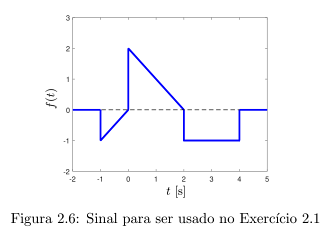
Apresente um esboço de cada um dos seguintes sinais:

a) $f(t-2)$.

b) $f(3-t)$.

c) $f(3-2 t)$.

**Comentários:** 
A questão **2.1** trata de algumas operações bastante comuns em sinais. Em particular, destacamos as operações elementares *deslocamento temporal, escalamento temporal* e *reversão temporal*, descritas abaixo e que, em geral, são combinadas. 

Inicialmente, vamos ilustrá-las através do sinal mais simples 

$$ f(t) = 
\begin{cases} 
e^{t/2}, \quad 1 \leq t < 5 \\ 0, \quad \text{caso contrário}
\end{cases},
$$
representado pelo gráfico abaixo:


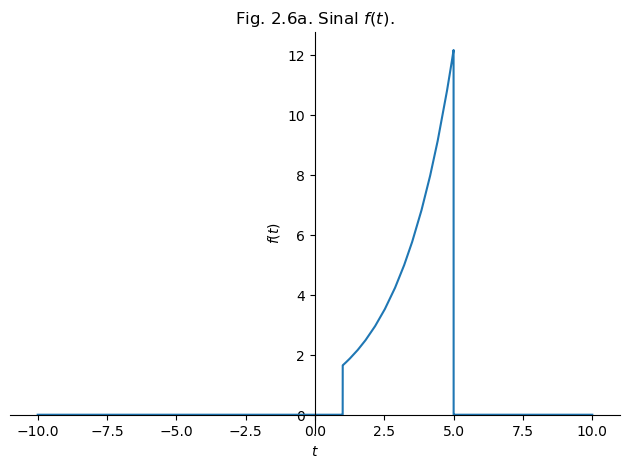

In [20]:
t = sym.Symbol('t')
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6a. Sinal $f(t)$.')

- Deslocamento temporal

No **deslocamento temporal** de um sinal por $T$ segundos, substituímos $t$ por $t − T$. Logo,  $x(t − T)$ representa $x(t)$ deslocado no tempo por $T$ segundos. 

Se $T$ for positivo, o deslocamento é para a direita (**atraso**). Se $T$ for negativo, o deslocamento é para a esquerda (**adianto**).

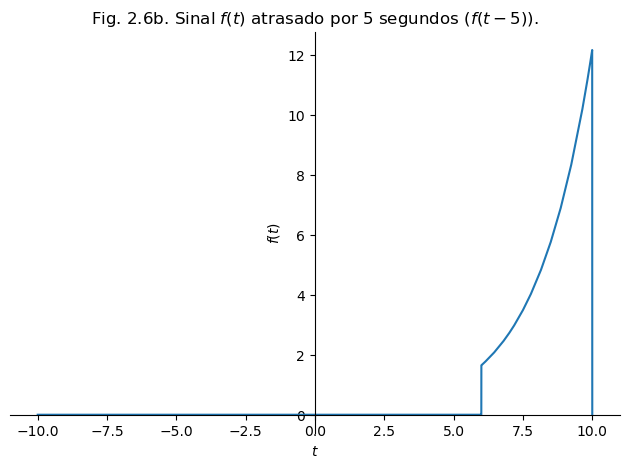

In [21]:
t = sym.Symbol('t')
a = 5
t = t - a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6b. Sinal $f(t)$ atrasado por %g segundos ($f(t - %g)$).' %(a,a))

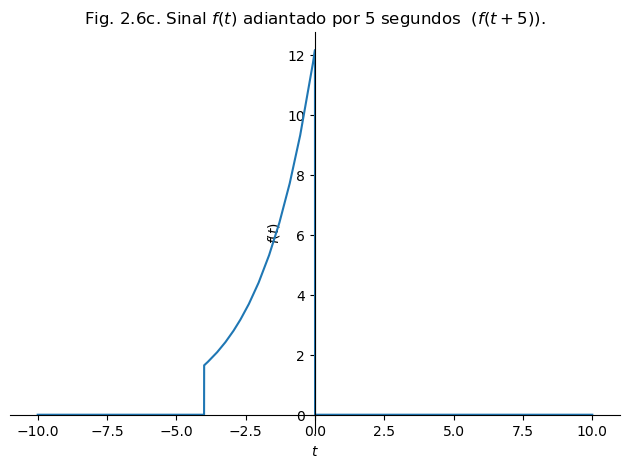

In [22]:
t = sym.Symbol('t')
a = 5
t = t + a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6c. Sinal $f(t)$ adiantado por %g segundos  ($f(t + %g)$).' %(a,a))

- Escalamento Temporal
 
A **compressão** ou **expansão** de um sinal no tempo é chamada de **escalamento temporal**. Considere o sinal $f(t)$ da Fig. 2.6a. 

O sinal da Fig. 2.6b é $x(t)$ comprimido no tempo por um fator de 2. Portanto, o que acontecer com $x(t)$ em algum instante $t$ também acontecerá com $\phi(t)$ no instante $t / 2$, logo

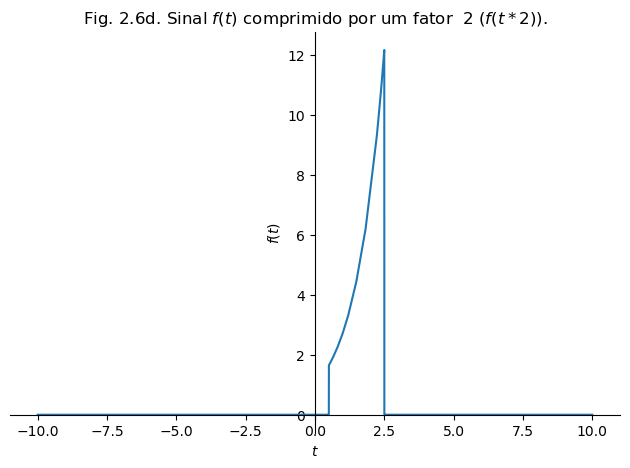

In [23]:
t = sym.Symbol('t')
a = 2
t = t*a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6d. Sinal $f(t)$ comprimido por um fator % g ($f(t*%g)$).' %(a,a))

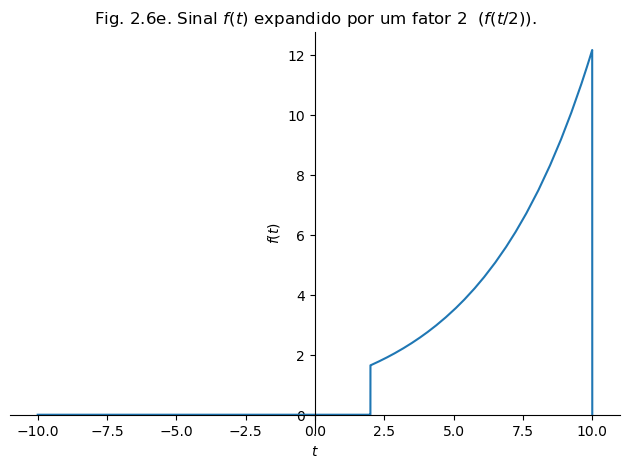

In [24]:
t = sym.Symbol('t')
a = 2
t = t/a
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6e. Sinal $f(t)$ expandido por um fator %g  ($f(t/%g)$).' %(a,a))

- Reversão Temporal

Considere o sinal $f(t)$ da Fig. 2.6a. Podemos ver $f(t)$ como uma forma rígida presa ao eixo vertical. Na reversão temporal de $f(t)$, rotacionamos esta forma em $180^{\circ}$ com relação ao eixo vertical. Essa reversão temporal (a reflexão de $x(t)$ com relação ao eixo vertical) nos fornece o sinal $f(-t)$ (Fig. 2.6f). 

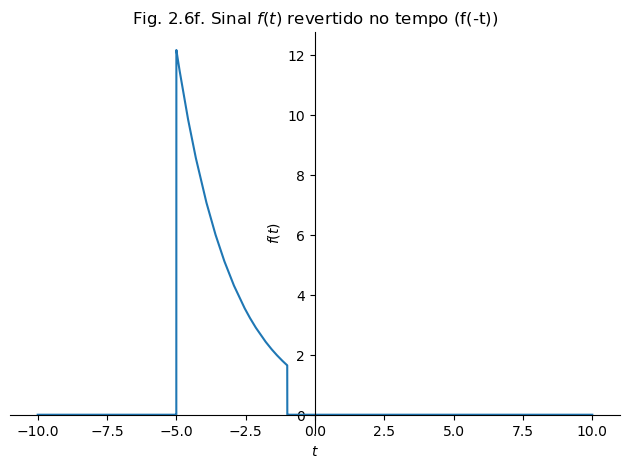

In [25]:
t = sym.Symbol('t')
t = -t
f = sym.Piecewise((exp(t/2), (1 <= t) & (t < 5)), (0, True))
sym.plot(f, title='Fig. 2.6f. Sinal $f(t)$ revertido no tempo (f(-t))')

**Solução:**

O sinal da figura 2.6 pode ser escrito como 

$$ f(t) = 
\begin{cases} 
0, \quad -1 < t \\ 
t, \quad -1 \leq t < 0 \\
2 - t, \quad 0 \leq t < 2 \\
-1, \quad 2 \leq t < 4 \\
0, \quad 4 < t
\end{cases},
$$

representado na figura  2.6e, abaixo

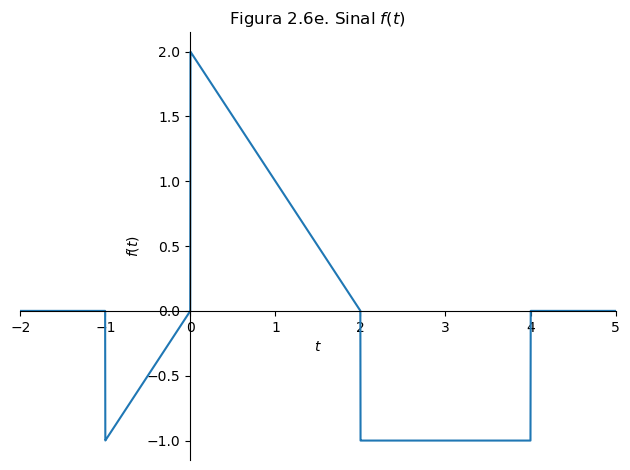

In [26]:
t = sym.Symbol('t')
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6e. Sinal $f(t)$', xlim = (-2,5))

Tem-se portanto, os seguintes sinais correspondentes:

a) $f(t-2)$.



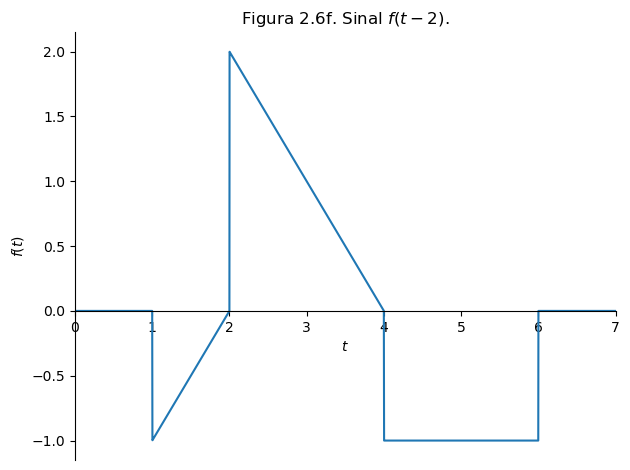

In [27]:
t = sym.Symbol('t')
a = 2
t = t - a
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6f. Sinal $f(t - %a)$.' %a, xlim = (0,7))

b) $f(3-t)$.

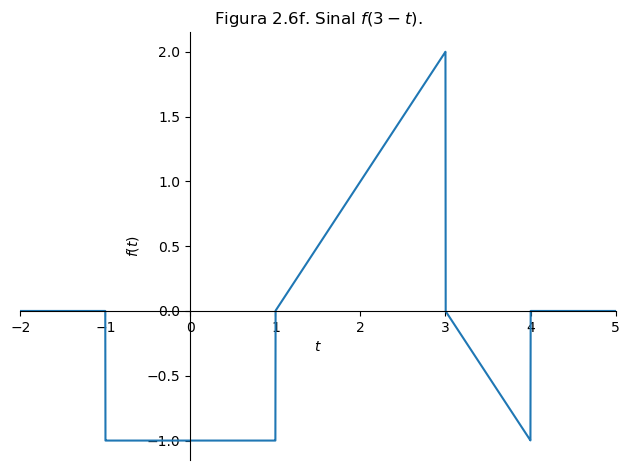

In [28]:
t = sym.Symbol('t')
a = 3
t = a - t
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6f. Sinal $f(%g - t)$.' %a, xlim = (-2,5))

c) $f(3-2 t)$.

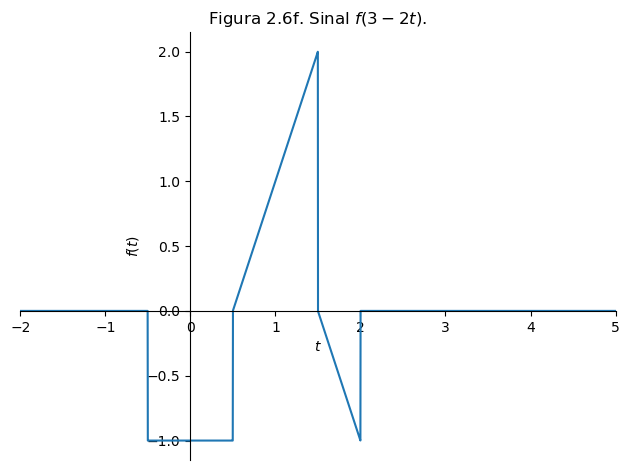

In [29]:
t = sym.Symbol('t')
a = 3
b = 2
t = a - b*t
f = sym.Piecewise((t, (-1 <= t) & (t < 0)), (2-t, (0 <= t) & (t < 2)), (-1, (2 <= t) & (t < 4)), (0, True))
sym.plot(f, title='Figura 2.6f. Sinal $f(%g - %g t)$.' %(a,b), xlim = (-2,5))

**Exercício 2.2** Considere o sinal $f(t)=e^{j \omega_1 t}+e^{j \omega_2 t}$ com dominio $\mathbb{R}$. Mostre que para este sinal ser periódico é necessário que a relação $\omega_1 / \omega_2$ seja um número racional. Se isto ocorrer, qual é o seu período? Aplique o resultado nos seguintes casos:

a) $\omega_1=2$ e $\omega_2=3$.

b) $\omega_1=2 \pi$ e $\omega_2=3 \pi$.

c) $\omega_1=2 / \pi$ e $\omega_2=3 / \pi$.

**Solução:**

Vamos denotar $f(t) = s_1(t) + s_2(t)$, onde $s_1(t) = e^{j \omega_1 t}$ e $s_2(t) = e^{j \omega_2 t}$.

Usando a identidade de Euler, tem-se que 

$$s_1(t) = cos(\omega_1 t) + jsin(\omega_1 t)$$

e

$$s_2(t) = cos(\omega_2 t) + jsin(\omega_2 t),$$

de onde se observa que os sinais $s_1(t)$ e $s_2(t)$ são periódicos com períodos fundamentais dados, respectivamente, por

$$ T_1 = \frac{2 \pi}{\omega_1} \text{ e } T_2 = \frac{2 \pi}{\omega_2}.$$

Como o período fundamental é o menor período e os múltiplos dos períodos fundamentais são períodos, o mínimo múltiplo comum entre $T_1$ e $T_2$ (caso exista) é o período fundamental de $f(t)$, isto é

$$f(t + T) = f(t), \quad \forall t \in \mathcal{D}(f), $$

com $T = mmc\{T_1,T_2\}$.

Assim, tem-se que devem existir dois inteiros $m,n \in \mathbb{N}$, tal que $T = mT_1 = nT_2$.
Donde de infere que $\frac{T_1}{T_2} = \frac{n}{m} \in \mathbb{Q}$ $\square$.

Temos portanto:

a) $\omega_1=2$ e $\omega_2=3 \Rightarrow T_1 = \pi, \quad T_2 = \frac{2 \pi}{3}$.

$T = 2 \pi.$

b) $\omega_1=2 \pi$ e $\omega_2=3 \pi \Rightarrow T_1 = 1, \quad T_2 = \frac{2}{3}$.

Resposta: $T = 2.$

c) $\omega_1=2 / \pi$ e $\omega_2=3 / \pi \Rightarrow T_1 = \pi^2, \quad T_2 = \frac{2 \pi^2}{3}$.

Resposta: $T = 2 \pi^2$.

**Exercício 2.3** Verifique se os seguintes sinais com dominio $\mathbb{R}$ são periódicos. Em caso afirmativo, determine o respectivo período.

a) $f(t)=\cos (\sqrt{2} t)$

b) $f(t)=2 \cos (3 t+2)-3 \sin(4 t-1)$

c) $f(t)=\cos (t)+\cos (\sqrt{2} t)$

d) $f(t)=e^{j(2 \pi / 3) t}$


e) $f(t)=e^{(-1+j 2 \pi / 3) t}$

f) $f(t)=e^{j t}+2 e^{j t / 3}$

g) $f(t)=\sum_{k=0}^{10} e^{j(\pi / 2) k t}$

h) $f(t)=\operatorname{sen}(2 \pi t)+\cos (5 \pi t)+\operatorname{sen}(3 \pi t)$

**Solução**

a) $f(t)=\cos (\sqrt{2} t)$: periódico com período $T = \frac{2\pi}{\sqrt{2}} = \pi \sqrt{2}.$

b) $f(t)=2 \cos (3 t+2)-3 \sin(4 t-1)$: como se trata de uma soma de funções periódicas com períodos dados por $T_1 = \frac{2 \pi}{3}$ e $T_2 = \frac{\pi}{2}$, o sinal $f(t)$ é periódico de período $T = 2 \pi$, como se observa nas figuras abaixo:

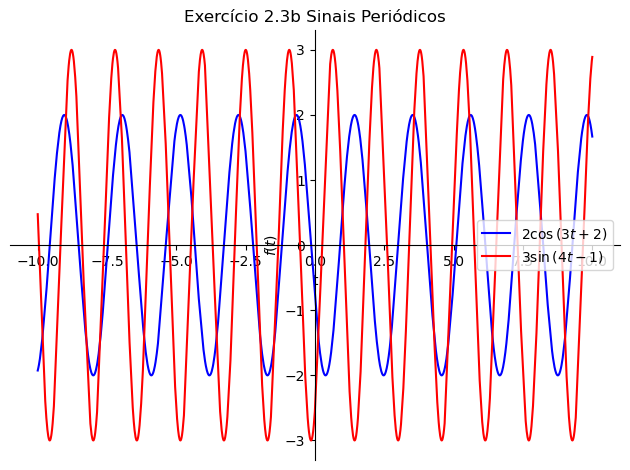

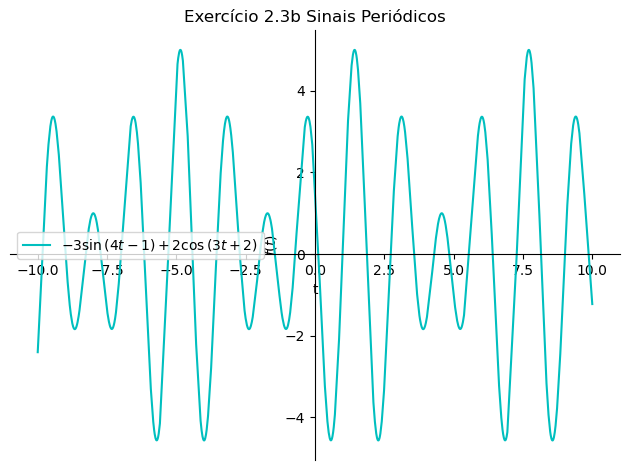

(None, None)

In [30]:
t = sym.Symbol('t')

s1 = 2*cos(3*t + 2)
s2 = 3*sin(4*t -1)

p1 = sym.plot(s1, s2, \
              title='Exercício 2.3b Sinais Periódicos', xlabel='t', legend=True, show=False)
p2 = sym.plot(s1 - s2, \
              title='Exercício 2.3b Sinais Periódicos', xlabel='t', legend=True, show=False)
p1[0].line_color = 'b'
p1[1].line_color = 'r'
p2[0].line_color = 'c'
p1.show(), p2.show()

c) $f(t)=\cos (t)+\cos (\sqrt{2} t)$: como $T_1 = 2 \pi$ e $T_2 = \sqrt{2} \pi$, $\frac{T_1}{T_2} \notin \mathbb{Q}$ e o sinal é aperiódico.

d) $f(t)=e^{j(2 \pi / 3) t}$: periódica com período $T = 3.$


e) $f(t)=e^{(-1+j 2 \pi / 3) t} = e^{-t}e^{(j 2 \pi / 3) t}$, que é o produto de um sinal aperiódico por um sinal periódico, que é aperiódico. Como o sinal $f(t)$ é complexo, vamos ilustrar suas partes real e complexa, nos gráficos abaixo:

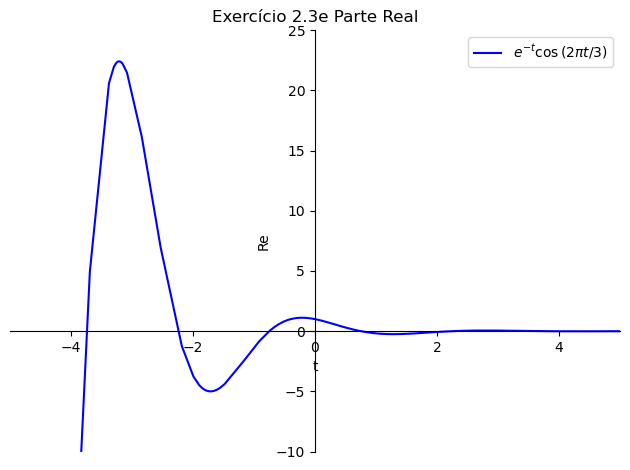

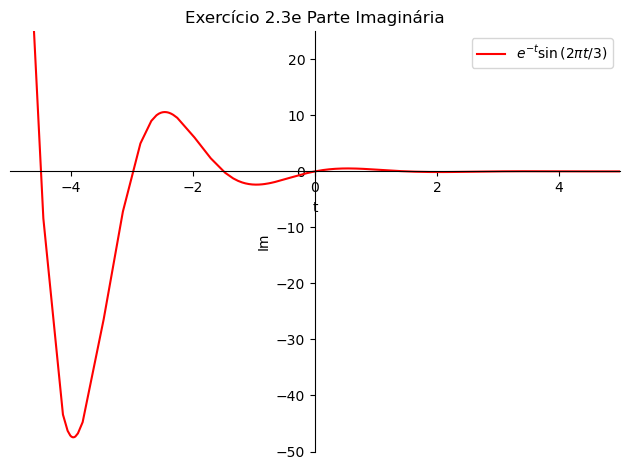

(None, None)

In [31]:
t = sym.Symbol('t')

s1 = exp(-t)*cos(2*pi*t/3)
s2 = exp(-t)*sin(2*pi*t/3)

p1 = sym.plot(s1, title='Exercício 2.3e Parte Real', xlim = (-5,5), ylim = (-10,25), xlabel='t', ylabel = 'Re', legend=True, show=False)
p2 = sym.plot(s2, title='Exercício 2.3e Parte Imaginária', xlim = (-5,5), ylim = (-50,25), xlabel='t', ylabel = 'Im', legend=True, show=False)
p1[0].line_color = 'b'
p2[0].line_color = 'r'
p1.show(), p2.show()

f) $f(t)=e^{j t}+2 e^{j t / 3}$

Neste caso temos a soma de dois sinais complexos periódicos, $f(t) = f_1(t) + f_2(t)$, onde $f_1(t) = e^{j t}$ tem período $T_1 = 2\pi$ e $f_2(t) = e^{j t/3}$ tem período $T_2 = 6\pi.$ Considerando o $mmc(2, 6) = 6$, tem-se que o sinal é periódico com período $T = 6\pi$. Abaixo, apresetamos as partes real e complexa do sinal em questão. 

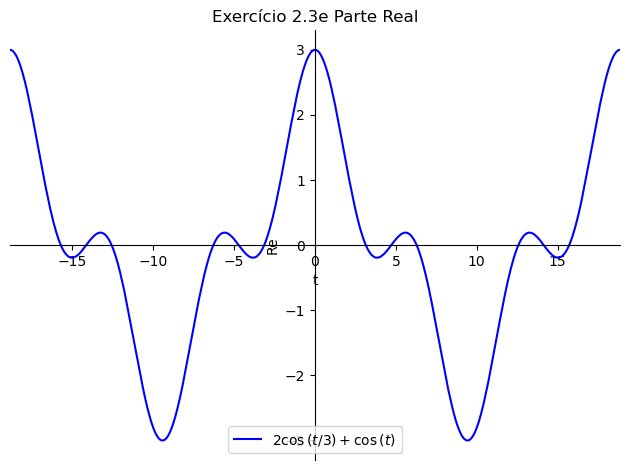

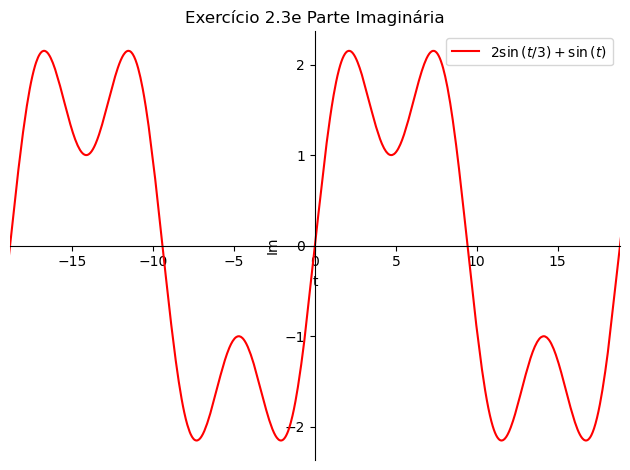

(None, None)

In [32]:
t = sym.Symbol('t',real=True)

s1 = cos(t) + 2*cos(t/3)
s2 = sin(t) + 2*sin(t/3)

p1 = sym.plot(s1,(t,-21,21), title='Exercício 2.3e Parte Real', xlim = (-6*pi,6*pi), xlabel='t', ylabel ='Re', legend=True, show=False)
p2 = sym.plot(s2,(t,-21,21), title='Exercício 2.3e Parte Imaginária',xlim = (-6*pi,6*pi), xlabel='t', ylabel ='Im', legend=True, show=False)
p1[0].line_color = 'b'
p2[0].line_color = 'r'
p1.show(), p2.show()

g) $f(t)=\sum_{k=0}^{10} e^{j(\pi / 2) k t}$

Neste caso, podemos escrever  $f(t)=1 + \sum_{k=1}^{10} e^{j(\pi / 2) k t}$, ou seja, uma constante, mais a soma de dez sinais periódicos, com períodos $T_k = 4/k, \quad \forall k = 1, \cdots, 10$. Como o mmc entre os períodos é $T = 4,$ temos um sinal períódico, como apresentado na figura abaixo.

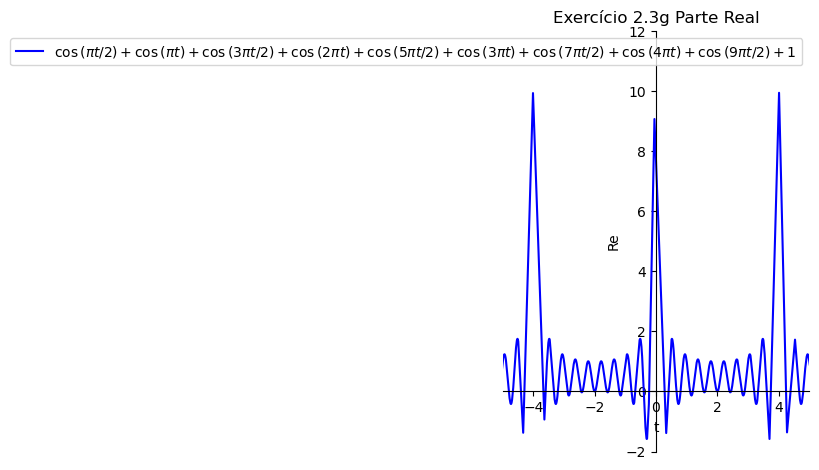

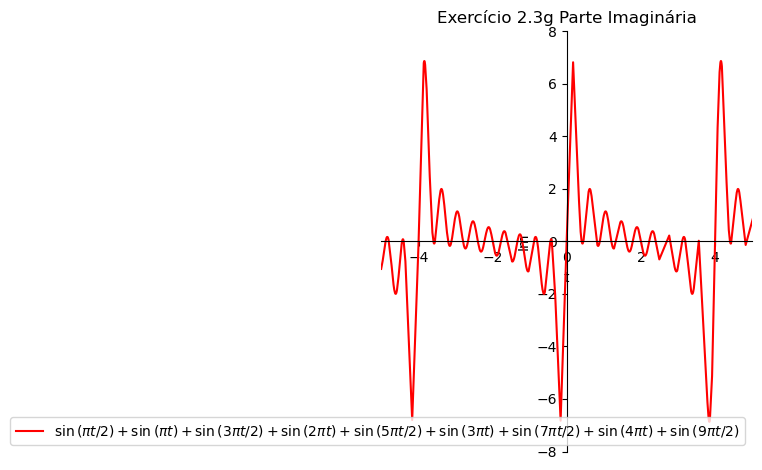

(None, None)

In [33]:
t = sym.Symbol('t',real=True)
s1 = 1
s2 = 0
for k in range(1,10):
    s1 = s1 + cos(k*pi*t/2)
    s2 = s2 + sin(k*pi*t/2)

p1 = sym.plot(s1,title='Exercício 2.3g Parte Real', xlim = (-5,5), ylim = (-2,12), xlabel='t', ylabel ='Re', legend=True, show=False)
p2 = sym.plot(s2, title='Exercício 2.3g Parte Imaginária', xlim = (-5,5), ylim = (-8,8),  xlabel='t', ylabel ='Im', legend=True, show=False)
p1[0].line_color = 'b'
p2[0].line_color = 'r'
p1.show(), p2.show()

h) $f(t)=\sin (2 \pi t)+\cos (5 \pi t)+\sin(3 \pi t)$
De modo análogo aos exercícios acima, este sinal é periódico com período $T = mmc\{1, \frac{2}{5},\frac{2}{3}\} = 2$, como vemos no gráfico abaixo:

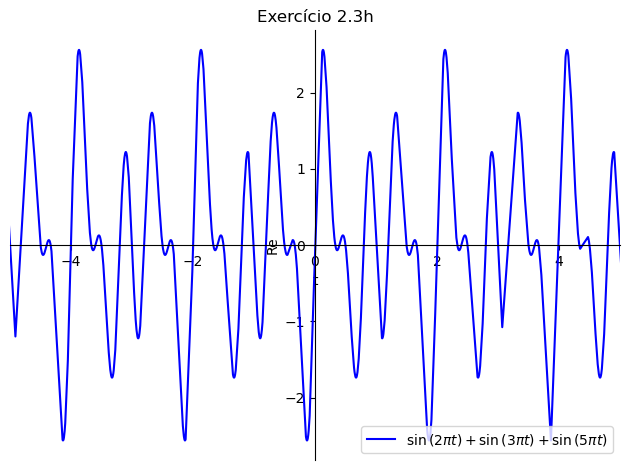

In [34]:
t = sym.Symbol('t',real=True)
s1 = sin(2*pi*t) + sin(5*pi*t) + sin(3*pi*t)
p1 = sym.plot(s1,title='Exercício 2.3h', xlim = (-5,5), xlabel='t', ylabel ='Re', legend=True, show=False)
p1[0].line_color = 'b'
p1.show()

**Exercício 2.4** Para os sinais a tempo discreto dados abaixo e definidos para todo $k \in$ $\mathbb{Z}$, verifique quais são periódicos e determine seus respectivos periodos.

a) $f(k)=\cos (\sqrt{2} k)$

b) $f(k)=\cos (8 \pi k / 31+2)$

c) $f(k)=2 \cos (3 \pi k+2)-3 \sin (2 \pi k / 3-1)$

d) $f(k)=e^{(-1+j 2 \pi / 3) k}$

e) $f(k)=e^{j \pi k}+2 e^{j(\pi / 3) k}$

f) $f(k)=1+e^{j(4 \pi / 9) k}+e^{j(2 \pi / 5) k}$

**Comentários:** além das condições estudadas para sinais a tempo contínuo, o período para sinais a tempo discreto deve ser um número natural.

a) $f(k)=\cos (\sqrt{2} k)$. Neste caso, como $\sqrt{2}N = m2 \pi$, para $m \in \mathbb{Z}$. Segue-se que $N \notin \mathbb{N}$ e, portanto, o sinal é aperiódico. 

b) $f(k)=\cos (8 \pi k / 31+2)$. Neste caso, $ 8 \pi N / 31 = m 2 \pi$, de onde segue-se que para $m=4$, $N = 31$ é o período fundamental, como se observa no gráfico abaixo



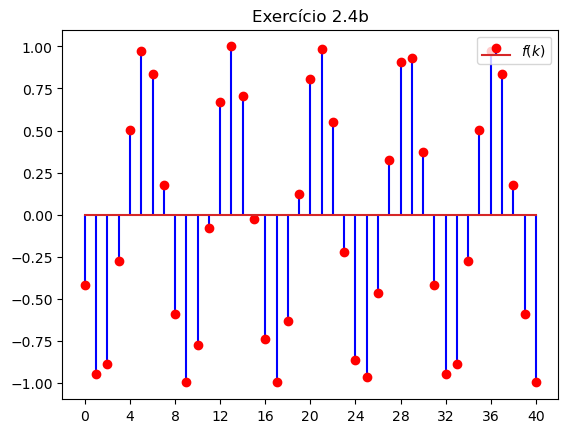

In [35]:
z = []
s1 = []
for k in range(0,41):
    z.append(k)
    s1.append(cos(8*pi*k/31 + 2))
       
plt.stem(z, s1, 'b', markerfmt='ro', label='$f(k)$')
plt.legend()
plt.title('Exercício 2.4b')
plt.xticks(range(0,41,4))
plt.show()

c) $f(k)=2 \cos (3 \pi k+2)-3 \sin (2 \pi k / 3-1)$. Neste caso, temos a soma de dois sinais: $s_1(k) = 2 \cos (3 \pi k+2)$, com período $N_1 = 2$, e $s_2(k) = 3 \sin (2 \pi k / 3-1)$, com período e $N_2 = 3$. O período de $f(k)$ é dado, portanto, por $N = mmc\{2,3\} = 6$. Como pode ser depreendido do gráfico abaixo

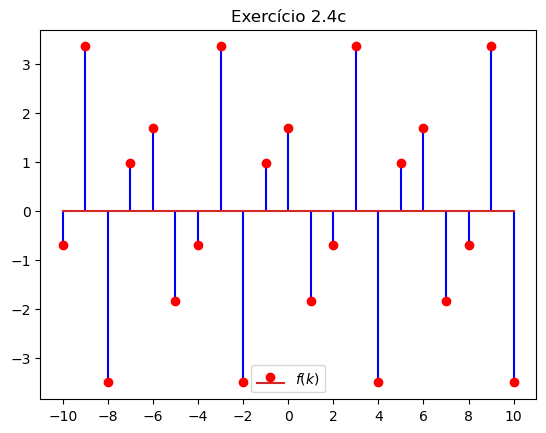

In [36]:
z = []
s1 = []
s2 = []
for k in range(-10,11):
    z.append(k)
    s1.append(2*cos(3*pi*k + 2))
    s2.append(3*sin(2*pi*k/3 - 1))
    
f = [(a - b) for a, b in zip(s1, s2)]
plt.stem(z, f, 'b', markerfmt='ro', label='$f(k)$')
plt.legend()
plt.title('Exercício 2.4c')
plt.xticks(range(-10,11,2))
plt.show()

d) $f(k)=e^{(-1+j 2 \pi / 3) k}$

Como se trata de um produto de um sinal aperioódico por um sinal periódico, resulta em um sinal **aperiódico** (análogo ao caso de sinais e tempo contínuo).

e) $f(k)=e^{j \pi k}+2 e^{j(\pi / 3) k}$. Neste caso, o sinal é dado pela soma de dois sinais complexos $s_1(k)  = e^{j \pi k}$, com período $N_1 = 2$ e $s_2(k)  = e^{j(\pi / 3) k}$, com período $N_2 = 6$. O período de $f(k)$ é, portando $N = mmc\{2,6\} = 6$. Abaixo apresentamos os gráficos das partes real e imaginária de $f(k)$.


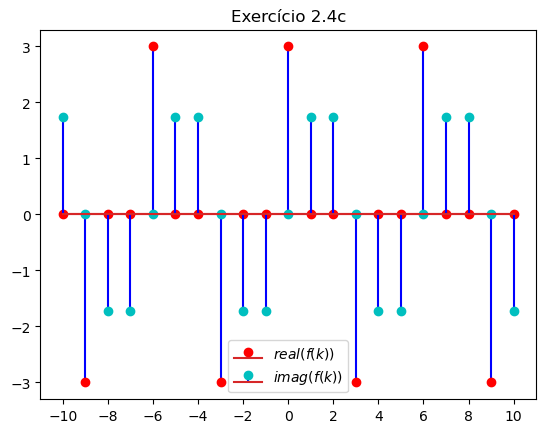

In [37]:
z = []
s1 = []
s2 = []
for k in range(-10,11):
    z.append(k)
    s1.append(cos(pi*k) + 2*cos(pi*k/3))
    s2.append(sin(pi*k) + 2*sin(pi*k/3))
    
plt.stem(z, s1, 'b', markerfmt='ro', label='$real(f(k))$')
plt.stem(z, s2, 'b', markerfmt='co', label='$imag(f(k))$')
plt.legend()
plt.title('Exercício 2.4c')
plt.xticks(range(-10,11,2))
plt.show()

f) $f(k)=1+e^{j(4 \pi / 9) k}+e^{j(2 \pi / 5) k}$

Neste caso, temos a soma de um sinal constante com dois sinais periódicos com períodos $N_1 = 9$ e $N_2 = 5$, respectivamente. Assim, o sinal resultante é periódico com sinal $N = 45$. O gráfico é apresentado abaixo

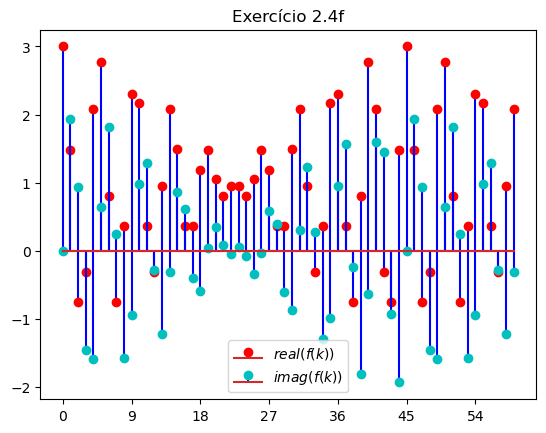

In [38]:
z = []
s0 = 1
s1 = []
s2 = []
for k in range(-0,60):
    z.append(k)
    s1.append(cos(4*pi*k/9) + cos(2*pi*k/5) + 1)
    s2.append(sin(4*pi*k/9) + sin(2*pi*k/5))
    
plt.stem(z, s1, 'b', markerfmt='ro', label='$real(f(k))$')
plt.stem(z, s2, 'b', markerfmt='co', label='$imag(f(k))$')
plt.legend()
plt.title('Exercício 2.4f')
plt.xticks(range(0,60,9))
plt.show()

**Exercício 2.5** Mostre que a relação $\int_{-\infty}^{\infty} f(t) \delta(t-\tau) d t=f(\tau)
$ é verdadeira. Em seguida, generalize este resultado e mostre que para $\alpha \in \mathbb{R}_{+}$ e $\tau \in \mathbb{R}$ a igualdade
$$
\int_{-\infty}^{\infty} f(t) \delta(\alpha t-\tau) d t=f(\tau / \alpha) / \alpha
$$
também é verdadeira.


**Solução:** Sendo $f(t)$ um sinal contínuo em $t=0$ e, por definição $\delta(t) \equiv 0, \quad \forall t \neq 0,$ temos que 
$$f(t)\delta(t) = f(0)\delta(t).$$
Segue-se, portanto que 
$$
\int_{-\infty}^{\infty} f(t) \delta(t-\tau) d t=  f(\tau)\int_{-\infty}^{\infty}  \delta(t-\tau) d t=f(\tau).
$$

Este resultado é conhecido como **Propriedade de amostragem do impulso unitário**.

Para demonstrar a propriedade requerida, note que 
$$
\int_{-\infty}^{\infty} f(t) \delta(\alpha t-\tau) d t=f(\tau / \alpha) \int_{-\infty}^{\infty} \delta(\alpha t-\tau) d t.
$$

Propondo a mudança de variáveis $\hat{t} = \alpha t - \tau$, temos que 

$$
f(\tau / \alpha) \int_{-\infty}^{\infty} \delta(\alpha t-\tau) d t = f(\tau / \alpha)\int_{-\infty}^{\infty} \delta(\hat{t}) \frac{d \hat{t}}{\alpha} = \frac{f(\tau / \alpha)}{\alpha}. \qquad \blacksquare
$$


**Exercício 2.6** Para os sinais a tempo contínuo dados abaixo, determine sua energia total $E$ e sua potência média $P$.

<p style="color: blue">Vamos utilizar $E = || \cdot ||^2$ e $P = || \cdot ||^2_{ef}$.</p>


a) $f(t)=\alpha$ para todo $t \in \mathbb{R}$ e $\alpha \in \mathbb{R}$.

Como se trata de um sinal constante, temos que $E(f) = \infty$ e $P(f) = \alpha^2$.

b) $f(t)=e^{-|t|}$ para todo $t \in \mathbb{R}$.



In [39]:
t = sym.Symbol('t')
T = sym.Symbol('T')
fp = exp(-t)
fn = exp(t)

E = integrate(fp*fp,(t,0,+oo)) + integrate(fn*fn,(t,-oo,0))
E

1

In [40]:
P = limit(integrate(fp*fp,(t,0,+T))/(2*T),T,oo ) + limit(integrate(fn*fn,(t,0,-T))/(2*T),T,oo )
P

0

c) $f(t)=0$ para $t<0$ e $f(t)=e^{-2 t}$ para $t \geq 0$.

Neste caso, temos

- $E(f) = \int_{-\infty}^{\infty} |f(t)|^2 dt = \int_{0}^{\infty}e^{-4 t} dt$

- $P(f) = lim_{T \rightarrow \infty}\frac{1}{2T}\int_{-T}^{T} |f(t)|^2 dt = lim_{T \rightarrow \infty}\frac{1}{2T}\int_{0}^{T} e^{-4 t} dt$

In [41]:
t = sym.Symbol('t')
T = sym.Symbol('T')
f = exp(-2*t)

E = integrate(f*f,(t,0,+oo))
E

1/4

In [42]:
P = limit(integrate(f*f,(t,0,+T))/(2*T),T,oo )
P

0

d) $f(t)=e^{(1+j) t}$ para $t<0$ e $f(t)=0$ para $t \geq 0$.

**Exercício 2.7** Considere o sinal $f(t)=e^{t+1} v(-t-1)$ definido para tado $t \in \mathbb{R}$.

a) Esboce a sua componente par $f_p(t)$ e a sua componente ímpar $f_i(t)$.

b) Determine a energia total do sinal $E$ e de suas componentes par $E_p$ e ímpar $E_i$.

c) Qual e a relação que existe entre $E_p$ e $E_i$? Determine para qual classe de sinais esta relação permanece válida.



**Solução:** Vamos escrever $f(t) = g(t)h(t),$ onde $g(t) = e^{t+1}$ e $h(t) = v(-t-1)$

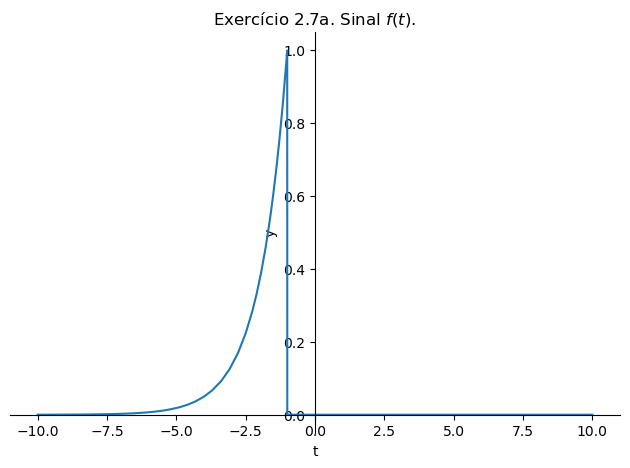

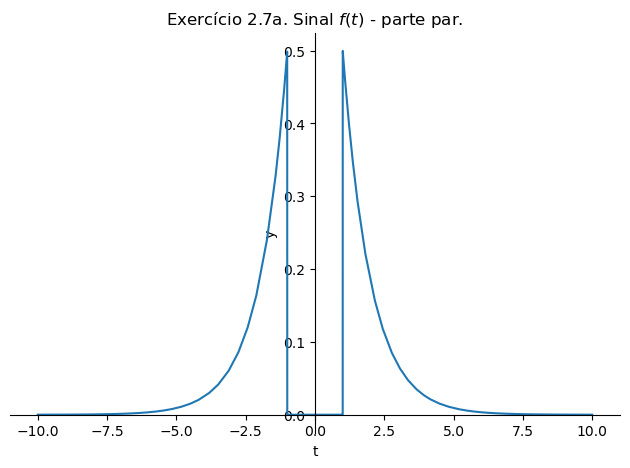

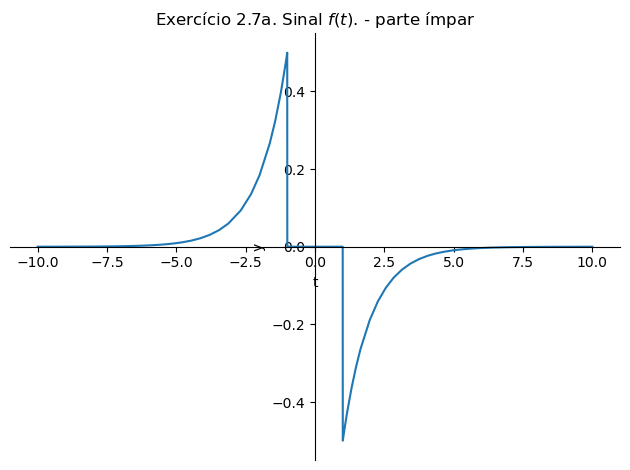

(None, None, None)

In [43]:
t = sym.Symbol('t')

g = exp(t + 1)
gm = exp(-t + 1) # para a componente ímpar
h = sym.Piecewise((1, -1 >= t), (0, True))
hm = sym.Piecewise((1, 1 <= t), (0, True)) # para a componente ímpar
f = g*h
fm = gm*hm

fp = 0.5*(f + fm)
fi = 0.5*(f - fm)
p1 = sym.plot(f, title='Exercício 2.7a. Sinal $f(t)$.', xlabel='t', ylabel ='y', show=False)

p2 = sym.plot(fp, title='Exercício 2.7a. Sinal $f(t)$ - parte par.', xlabel='t', ylabel ='y', show=False)

p3 = sym.plot(fi, title='Exercício 2.7a. Sinal $f(t)$. - parte ímpar', xlabel='t', ylabel ='y', show=False)

p1.show(), p2.show(), p3.show()


In [44]:
t = sym.Symbol('t')
f = exp(t + 1)

E = (integrate(f*f,(t,-oo,-1)))
E

1/2

In [45]:
t = sym.Symbol('t')
g = 0.5*exp(t + 1)
gm = 0.5*exp(-t + 1)
Ep = (integrate(g*g,(t,-oo,-1)) + integrate(gm*gm,(t,1,+oo)))
Ep

0.250000000000000

In [46]:
t = sym.Symbol('t')
g = 0.5*exp(t + 1)
gm = -0.5*exp(-t + 1)
Ei = (integrate(g*g,(t,-oo,-1)) + integrate(gm*gm,(t,1,+oo)))
Ei

0.250000000000000

No presente exercício, tem-se que $E = E_p + E_i$. 

Como provamos (em sala da aula) que a parte par e a parte ímpar de um sinal (complexo) são ortogonais, temos que 

$$
E = \langle  f\; , \;f^* \rangle =  \langle  (f_p + f_i)\; , \;(f_p + f_i)^* \rangle = |f_p|^2 + |f_i|^2,
$$

De onde segue-se que $E = E_p + E_i$, para sinais a tempo contínuo.

**Exercício 2.8** Considere um circuito $R C$ série com constante de tempo $c_0=0.5[\mathrm{~s}]$, alimentado por uma fonte de tensão $f(t)$. Em $t=0$ a tensão no capacitor é nula e a fonte é conectada. Determine a energia total $E$ e a potência média $P$ da tensão produzida no capacitor $f_c(t)$, considerando

a) $f(t)=10[\mathrm{~V}]$ para todo $t \geq 0$.

b) $f(t)=10 \operatorname{sen}(t / 4)[\mathrm{V}]$ para todo $t \geq 0$.


**Solução**  do exemplo 2.16, um circuito RC série alimentado por uma tensão $g(t)$ é um sistema LIT causal. A tensão no capacitor tem como resposta ao impulso dada por $h(t)=0$ para todo $t<0$ e
$$
h(t)=\left(1 / c_0\right) e^{-t / c_0}, \forall t \geq 0
$$
em que $c_0=R C[\mathrm{~s}]$ é a sua constante de tempo. 


Assim, utilizando
$$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau & , \quad t \geq 0 \\
0 & , \quad t<0
\end{array}\right.
$$
temos $\forall t \geq 0:$

- a) $f_c(t) = \left(1 / c_0\right)\int_0^t 10  e^{(-t + \tau) / c_0} d \tau = 20e^{-2t}\int_0^t e^{2 \tau} d \tau, \quad \forall t \geq 0;$

- b) $f_c(t) = \left(1 / c_0\right)\int_0^t 10 sen(\tau/4) e^{(-t + \tau) / c_0} d \tau = 20e^{-2t}\int_0^t sen(\tau/4)  e^{2\tau} d \tau, \quad \forall t \geq 0.$

Para o item a), temos

In [47]:
t, tau = symbols('t tau')
fca = simplify(20*exp(-2*t)*integrate(exp(2*tau),(tau,0,t)))
fca

10 - 10*exp(-2*t)

Como $\operatorname{lim}_{t \to \infty}F_{ca} \not\to\ 0$, temos que $E = \infty$. Por outro lado, a potência média é dada por 

$$P  = ||f_{ca}||^2_{ef} = \operatorname{lim}_{\tau \to \infty} \frac{1}{2 \tau} \int_0^{\tau} |f_{ca}(t)|^2 d\tau$$


In [48]:
P = limit(integrate(fca**2,(t,0,tau))/(2*tau),tau,oo)
P

50

Para o item b). temos

In [49]:
t, tau = symbols('t tau')
fcb = simplify(20*exp(-2*t)*integrate(sin(tau/4)*exp(2*tau),(tau,0,t)))
fcb

128*sin(t/4)/13 - 16*cos(t/4)/13 + 16*exp(-2*t)/13

Como $\operatorname{lim}_{t \to \infty}f_{cb} \not \to 0$, $E = + \infty$. O cálculo da potência é dado por

In [50]:
P = simplify(integrate(fcb**2,(t,0,tau))/(2*tau))
s = limit(P,tau,+oo)
s.doit()

Limit(32*((130*tau - 252*sin(tau/2) + 64*cos(tau/2) - 63)*exp(4*tau) - 32*exp(2*tau)*sin(tau/4) - 1)*exp(-4*tau)/(169*tau), tau, oo, dir='-')

Vamos calcular dois limites separadamente:

In [51]:
aux1 = limit((130*t - 252*sin(t/4) + 64*cos(t/2) - 63)/t,t,+oo)*32/169
aux1

320/13

In [52]:
aux2 = limit((-32*exp(-2*t)*sin(t/4) - exp(-4*t))/t,t,+oo)*32/169
aux2

0

Assim, $P = 320/13$.

**Exercício 2.9** Para os sinais a tempo discreto dados abaixo, determine sua energia total $E$ e sua potência média $P$.

a) $f(k)=\alpha$ para todo $k \in \mathbb{Z}$ e $\alpha \in \mathbb{Z}$.

b) $f(k)=e^{-|k|}$ para todo $k \in \mathbb{Z}$.

c) $f(k)=0$ para $k<0 \in \mathbb{Z}$ e $f(k)=e^{-2 k}$ para $k \geq 0 \in \mathbb{Z}$.


d) $f(k)=e^{(1+j) k}$ para $k<0 \in \mathbb{Z}$ e $f(k)=0$ para $k \geq 0 \in \mathbb{Z}$.

**a)** A energia é infinita e a potência média dada por $P = \alpha^2$.

De fato, 

$$
P = \frac{1}{2m + 1} \sum_{-m}^{m} \alpha^2 = \alpha^2.
$$

**b)** Neste caso, podemos escrever 
$$ E = 2\sum_0^{\infty} e^{-2k} - 1. $$
Como $z = e^{-2}<1$, podemos usar o **Lema 2.1** que implica que $ \sum_{k=0}^{\infty} z^k=1 /(1-z) $,
 e concluir que 
 
 $$
 E = 2\frac{1}{1 - e^{-2}} - 1 = \frac{e^2 + 1}{e^2 - 1}.
 $$
 e 
 $$
 P = 0.
 $$

**c)** De modo análogo ao caso anterior
$$ E = \sum_0^{\infty} e^{-4k}. $$
Como $z = e^{-4}<1$, podemos usar o **Lema 2.1** 
 e concluir que 
 
 $$
 E = \frac{1}{1 - e^{-4}} = \frac{e^{4}}{e^{4} - 1}
 $$
 e $ P = 0.$

**d)** Neste caso, temos
$$
E = \sum_{k = -\infty}^{-1}e^{2k} = \sum_{s = 1}^{\infty}e^{-2s} = \sum_{s = 0}^{\infty}e^{-2s} - 1
$$

Assim, 

$$E = \frac{1}{1 - e^{-2s}} = \frac{e^{2s}}{e^{2s} - 1}
$$
e $P = 0$.

**Exercício 2.10** Considere o sinal $f(t)=e^{-|t-1|}$, definido para todo $t \in \mathbb{R}$.

a) Determine a sua componente par $f_p(t)$ e a sua componente impar $f_i(t)$.

b) Em um mesmo gráfico, esboce $f(t), f_p(t)$ e $f_i(t)$ para $-5 \leq t \leq 5$.

c) Para cada um dos sinais $f(t), f_p(t)$ e $f_i(t)$ determine $E, E_p$ e $E_i$.

d) Qual é a relaçẫo que existe entre $E$ e $E_p+E_i$ \& Esta relação é válida para qualquer sinal $f(t)$ dado?


**a)** 
$$
f_p(t) = \frac{1}{2}\left(e^{-|t-1|} + e^{-|-t-1|} \right);
$$
e
$$
f_i(t) = \frac{1}{2}\left(e^{-|t-1|} - e^{-|-t-1|} \right).
$$

**b)**

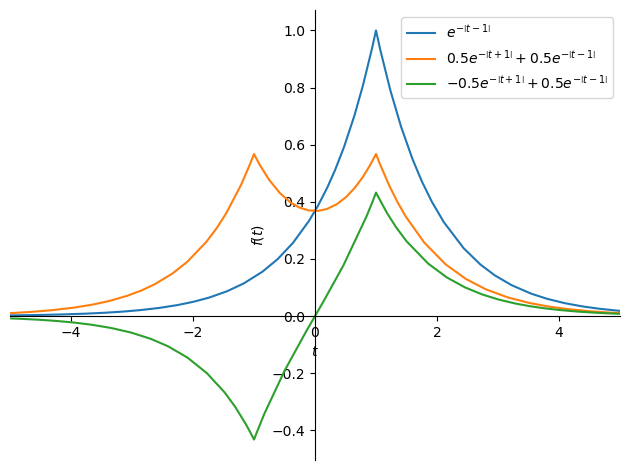

In [53]:
t = sym.Symbol('t')

f = exp(-abs(t-1))
fp = 0.5*(exp(-abs(t-1)) + exp(-abs(-t-1)))
fi = 0.5*(exp(-abs(t-1)) - exp(-abs(-t-1)))

sym.plot(f,fp, fi, xlim = (-5,5), legend = "True")

In [54]:
f = exp(-abs(t-1))
E = integrate(f**2,(t,-oo,oo))
E

1

Vamos observar que 
$$
\begin{aligned}
f_p(t) & = 0.5(f(t) + \tilde{f}(t)) \\
f_i(t) & = 0.5(f(t) - \tilde{f}(t)),
\end{aligned}$$
onde 
$$
\tilde{f}(t) = e^{-|-t-1|}
$$
e  a energia $\tilde{E}$ associada a $\tilde{f}(t)$ é dada por

In [55]:
ft = exp(-abs(-t-1))
Et = integrate(ft**2,(t,-oo,oo))
Et

1

Por outro lado, o produto interno entre $f$ e $\tilde{f}$ é dado por

In [56]:
integrate(f*ft,(t,-oo,oo))

Integral(exp(-Abs(t - 1))*exp(-Abs(t + 1)), (t, -oo, oo))

Das definições de função par e produto interno, segue que 
$$
E_p = \frac{1}{4} \langle f + \tilde{f}, f + \tilde{f} \rangle   = \frac{1}{4} E + \frac{1}{4} \tilde{E} + \frac{1}{2} \langle f , \tilde{f} \rangle = \frac{1}{4} + \frac{1}{4} + \frac{1}{2}  = 1.
$$

Analogamente, 
$$
E_i = \frac{1}{4} \langle f - \tilde{f}, f - \tilde{f} \rangle   = \frac{1}{4} E + \frac{1}{4} \tilde{E} - \frac{1}{2} \langle f , \tilde{f} \rangle = \frac{1}{4} + \frac{1}{4} - \frac{1}{2}  = 0.
$$

**d)** A relação obtida é que $E = E_p + E_i$, válida para qualquer sinal, tendo-se em vista que as partes par e ímpar de um sinal são ortogonais.

**Exercício 2.11** Considere $g(t)$ e $h(t)$ dois sinais reais definidos para todo $t \in \mathbb{R}$, ambos com energia finita. A partir desses sinais defina $f(t)=g(t)+h(t)$.

a) Qual é a condição para assegurar que $E_f=E_g+E_h$ ?

 - Necessariamente, $\langle g(t), h(t)  \rangle = 0$. Ou seja $g(t)$ e $h(t)$ devem ser ortogonais.

b) Para $f(t)=e^{-|t+1|}$, determine $g(t)$ e $h(t)$ que satisfaçam a condição do item anterior e não sejam as componentes par 
e ímpar de $f(t)$.



In [57]:
t = sym.Symbol('t')
a = sym.Symbol('a')
f = exp(-abs(t+1)) - (4/3)*exp(-2*abs(t+1))
g = (4/3)*exp(-2*abs(t+1))
E = integrate(f*g,(t,-oo,oo))
E.doit()

0

c) Determine a potência média de $f(t)$ no intervalo $-5 \leq t \leq 5$.


In [58]:
t = sym.Symbol('t')
f = exp(-abs(t+1))
P = integrate(f**2,(t,-5,5))/10
simplify(P)

(-exp(4) - 1 + 2*exp(12))*exp(-12)/20

**Exercício 2.12** Considere o sinal a tempo discreto $f(k)=(1 / 2)^{|k-2|}$ definido para todo $k \in \mathbb{Z}$.

a) Determine a sua componente par $f_p(k)$ e a sua componente ímpar $f_i(k)$.

 **a)** 
 $$
 f_p(k) = \frac{1}{2}\left((1 / 2)^{|k-2|} + (1 / 2)^{|-k-2|}\right) = (1 / 2)^{|k-2|+1} + (1 / 2)^{|-k-2|+1}
 $$
 e
$$
f_i(k) = \frac{1}{2}\left((1 / 2)^{|k-2|} - (1 / 2)^{|-k-2|}\right) = (1 / 2)^{|k-2|+1} - (1 / 2)^{|-k-2|+1}
$$




b) Em um mesmo gráfico, esboce $f(k), f_p(k)$ e $f_i(k)$ para $-5 \leq k \leq 5$.

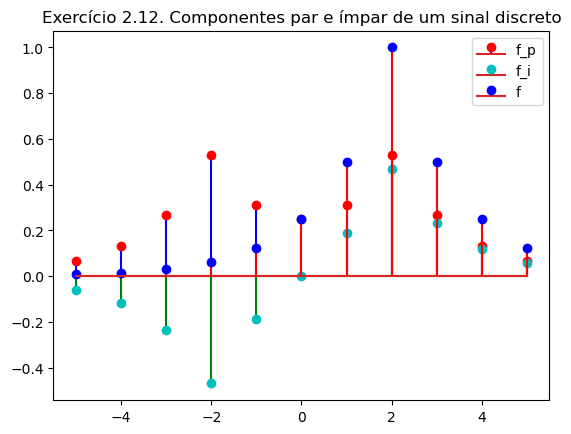

In [59]:
z = []
z1 = []
z2 = []
for k in range(-5,6):
    z.append(k)
    z1.append(0.5**(abs(k -2)))
    z2.append(0.5**(abs(- k -2)))
s1 = z1
s2 = [(a + b)*0.5 for a, b in zip(z1, z2)]
s3 = [(a - b)*0.5 for a, b in zip(z1, z2)]

plt.stem(z, s2, 'b', markerfmt='ro', label='f_p')
plt.stem(z, s3, 'g', markerfmt='co', label='f_i')
plt.stem(z, s1, 'r', markerfmt='bo', label='f')
plt.legend()
plt.title('Exercício 2.12. Componentes par e ímpar de um sinal discreto')
plt.show()

c) Para cada um dos sinais $f(k), f_p(k)$ e $f_i(k)$ determine $E, E_p$ e $E_i$.



d) Qual é a relação que existe entre $E$ e $E_p+E_i$ \& Esta relação é válida para qualquer sinal $f(k)$ dado?

e) Considerando $f(k)=g(k)+h(k)$, qual é a condição para assegurar que $E_f=$ $E_g+E_h$ ?

f) Determine $g(k)$ e $h(k)$ que satisfaçam a condição do item anterior e não sejam as componentes par e ímpar de $f(k)$.

g) Determine a sua potência média no intervalo $-5 \leq k \leq 5$.

**Exercício 2.13** Um sistema com entrada $g(t)$ ou $g(k)$ possui saída $y(t)$ ou $y(k)$, respectivamente. Verifique para cada um dos casos se o sistema é linear, invariante no tempo e causal.

a) $y(t)=\alpha g(t)+\beta, \alpha \in \mathbb{R}$ e $\beta \in \mathbb{R}$.

b) $y(t)=g(\operatorname{sen}(t))$.

c) $y(k)=g(k-2)^2$.

d) $y(k)=g(k+1)-g(k-1)$.


**a)** $y(t)=\alpha g(t)+\beta, \alpha \in \mathbb{R}$ e $\beta \in \mathbb{R}$.

Vamos considerar 
$$
\begin{aligned}
y_1(t)&=\alpha g_1(t)+\beta, \\
y_2(t)&=\alpha g_2(t)+\beta.
\end{aligned}
$$
Para que o sistema seja linear, devemor ter
$$
y_1(t) + y_2(t) =\alpha (g_1(t)+ g_2(t)) + \beta \neq \alpha (g_1(t)+ g_2(t)) + 2\beta,
$$
a não ser no caso especial em que $\beta = 0$, caso contrário ($\beta \neq 0$), o sistema é não linear.

Como à entrada $g(t -\tau)$, corresponde à saída $y(t - \tau )=\alpha g(t -\tau) + \beta$, associada à $g(t)$, o sistema é invariante no tempo.

Finalmente, o sistema depende apenas da entrada $g(\tau)$ para $t \geq \tau$, sendo causal.

b) $y(t)=g(\operatorname{sen}(t))$.



c) $y(k)=g(k-2)^2$.

d) $y(k)=g(k+1)-g(k-1)$.


**Exercício 2.14** Um sistema linear, causal e invariante no tempo apresenta a saída $y(t)$ correspondente à entrada $g(t)$. Determine a sua resposta ao impulso unitário, a sua resposta ao degrau unitario e verifique se o sistema é estável.

a) $g(t)=2 e^{-t} v(t), y(t)=e^{-t} v(t)$.

b) $g(t)=e^{-2 t} v(t), y(t)=\left(e^{-t}-e^{-2 t}\right) v(t)$.

c) $g(t)=e^{-t} v(t), y(t)=\operatorname{sen}(t) v(t)$.

d) $g(t)=e^{-t} v(t), y(t)=\cos (t) v(t)$.


**Exercício 2.15** Um sistema linear, causal e invariante no tempo apresenta a saida $y(k)$ correspondente à entrada $g(k)$. Determine a sua resposta ao impulso unitário, $a$ sua resposta ao degrau unitário e verifique se o sistema é estável.

a) $g(k)=2^k v(k), y(k)=2^k v(k)$.

b) $g(k)=2^k v(k), y(k)=\left(3^k-2^k\right) v(k)$.

c) $g(k)=2^{-k} v(k), y(k)=\operatorname{sen}(\pi k / 4) v(k)$.

d) $g(k)=2^{-k} v(k), y(k)=\cos (\pi k / 4) v(k)$.


**Exercício 2.16** Para uma entrada $g(t)$ um sistema causal a tempo contínuo apresenta uma saida $y(t)$ que satisfaz $y(t)-\alpha y(t-T)=g(t)$, onde $\alpha \in \mathbb{R}$ e $T>0$.

a) Este sistema é linear? É invariante no tempo?

b) Determine a sua resposta ao impulso unitário.

c) Determine a sua resposta ao degrau unitário.

d) Determine os valores de $\alpha$ para os quais ele é estável.

e) Refaça todos os itens acima, mas agora considerando a sua versäo a tempo discreto dada por $y(k)-\alpha y(k-1)=g(k)$.


**Exercício 2.17** Verifique se o valor da fase $\psi$ do sinal estudado no Exemplo 2.10 pode ser expresso na forma
$$
\psi=-\operatorname{tg}^{-1}\left\{\frac{1-\cos (2 \theta)}{\operatorname{sen}(2 \theta)}\right\}
$$

$$\color{red}{\text{Favor desconsiderar esse exercício}}$$

**Exercício 2.18** Uma estratégia útil para determinar somas de potências é ilustrada através dos seguintes cálculos, que devem ser realizados analiticamente.

a) Considerando que $\sum_{k=1}^r(k+1)^2-\sum_{k=1}^r k^2=(r+1)^2-1$, determine $\sum_{i=1}^r k$.


**a)** 
$$
\begin{aligned}
\sum_{k=1}^r(k+1)^2-\sum_{k=1}^r k^2 &= \sum_{k=1}^r k^2 + 2\sum_{k=1}^r k +  \sum_{k=1}^r 1 -\sum_{k=1}^r k^2    \\
& = 2\sum_{k=1}^r k + r = (r+1)^2-1. \\
& 
\end{aligned}
$$
Daí, podemos reescrever
$$
2\sum_{k=1}^r k  = r^2 + r
$$
Donde se segue que 

$$
\sum_{k=1}^r k  = \frac{r(r + 1)}{2} .
$$

b) Considerando que $\sum_{k=1}^r(k+1)^3-\sum_{k=1}^r k^3=(r+1)^3-1$, determine $\sum_{i=1}^r k^2$.

**b)** 
$$
\begin{aligned}
\sum_{k=1}^r(k+1)^3-\sum_{k=1}^r k^3 &= \sum_{k=1}^r k^3 + 3\sum_{k=1}^r k^2 + 3\sum_{k=1}^r k + \sum_{k=1}^r 1 -\sum_{k=1}^r k^3    \\
& = 3\sum_{k=1}^r k^2 + 3\frac{r(r+1)}{2} + r = (r+1)^3-1. \\
& 
\end{aligned}
$$
Daí, podemos reescrever
$$
6\sum_{k=1}^r k^2  = 2(r+1)^3-2 - 3r(r+1) - 2r = r(2r + 1)(r + 1).
$$
Donde se segue que 

$$
\sum_{k=1}^r k^2  = \frac{r(2r + 1)(r + 1)}{6} .
$$